This is a Python code in PyTorch for denoising of MRSI data using separate spatial and spectral denoising pipeline. It includes the whole spectrum: from data preparation, visualization, pre-processing, separate spatial and spectral pipelines, reconstruction, performance analysis, and visualization after processing (frequency and time domain analysis)

In [ ]:
import os
from pathlib import Path

# Root project directory
PROJECT_ROOT = Path.cwd()

# Data directories
DATA_DIR = PROJECT_ROOT / "data"
NOISY_DIR = DATA_DIR / "noisy"
REFERENCE_DIR = DATA_DIR / "lr_denoised"

# Output directories
OUTPUT_DIR = PROJECT_ROOT / "outputs"

SPATIAL_OUTPUT_DIR = OUTPUT_DIR / "spatial"
SPECTRAL_OUTPUT_DIR = OUTPUT_DIR / "spectral"
RECON_OUTPUT_DIR = OUTPUT_DIR / "reconstructed"

# Create output folders automatically
SPATIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPECTRAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
#import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import h5py
import random
from sklearn.model_selection import train_test_split
import scipy.ndimage as nd
import glob

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
DATA_DIR = "data/"
OUTPUT_DIR = "outputs/"

In [ ]:
# Path to the folder containing the noisy data
noisy_folder_path = NOISY_DIR
reference_path = REFERENCE_DIR

In [ ]:
##### Step 1...Data Visualization ###

In [ ]:
#Load any MATLAB MRSI file and extract complex 5D CSI data
def load_mat_csi(mat_path):
    mat = scipy.io.loadmat(mat_path)
    csi_struct = mat['csi'][0, 0]

    # unwrap the nested CSI["Data"]
    raw = csi_struct['Data']
    while isinstance(raw, np.ndarray) and raw.size == 1:
        raw = raw[0]
    raw = np.squeeze(raw)       # should be [22,22,21,96,8] complex

    # convert to torch complex tensor
    csi_t = torch.from_numpy(raw.astype(np.complex64)).to(device)

    # load mask
    mask = torch.from_numpy(mat['mask'].astype(bool)).to(device)

    # load acquisition parameters
    Par = mat['Par'][0, 0]
    csi_par = Par['CSI'][0, 0]

    dwell_ns = float(csi_par['Dwelltimes'][0, 0])       # nanoseconds
    f0 = float(csi_par['LarmorFreq'][0, 0])             # Larmor Freq in Hz
    dt = dwell_ns * 1e-9                                # dwell time in seconds
    center_ppm = 4.8

    return csi_t, mask, dt, f0, center_ppm


In [ ]:
#Make a clear 3D magnitude map from raw CSI
def make_structural(csi_t, mask, t_window=8, phase_idx=0):
    data_phase = csi_t[..., phase_idx]     # [X,Y,Z,T]
    mag = data_phase.abs()
    early = mag[..., :t_window]
    vol = torch.sqrt(torch.mean(early**2, dim=-1))

    vol = vol * mask
    vol = vol - vol.min()
    vol = vol / (vol.max() + 1e-8)
    return vol


In [ ]:
#Extract FID and spectrum in ppm
def get_FID(csi_t, x, y, z, phase_idx=0):
    return csi_t[x, y, z, :, phase_idx].detach().cpu().numpy()

def get_spectrum_ppm(csi_t, x, y, z, dt, f0, center_ppm, phase_idx=0):
    FID = get_FID(csi_t, x, y, z, phase_idx)
    Spec = np.fft.fftshift(np.fft.fft(FID))

    n = len(Spec)
    Fs = 1.0 / dt
    freq_Hz = np.linspace(-Fs/2, Fs/2, n, endpoint=False)
    ppm = center_ppm + freq_Hz * 1e6 / f0

    return ppm, Spec


In [ ]:
#Plot 3D slice with voxel marker plus FID
def plot_image_with_FID(vol3d, csi_t, x, y, z, dt, title="MRSI and FID", phase_idx=0):
    img = vol3d[:, :, z].detach().cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    img = nd.gaussian_filter(img, sigma=1.0)

    FID = get_FID(csi_t, x, y, z, phase_idx)
    t = np.arange(len(FID)) * dt * 1e3

    plt.figure(figsize=(12,5), dpi=150)

    # left panel. 3D slice
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray', origin='lower', interpolation='bicubic')
    plt.scatter(y, x, s=120, facecolors='none', edgecolors='red')
    plt.axis('off')
    plt.title(title + " slice")

    # right panel. FID magnitude
    plt.subplot(1,2,2)
    plt.plot(t, np.abs(FID))
    plt.xlabel("Time (ms)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)
    plt.title("FID at voxel (x={}, y={}, z={})".format(x, y, z))

    plt.tight_layout()
    plt.show()


In [ ]:
#Plot 3D slice with voxel marker plus spectrum in ppm
def plot_image_with_spectrum(vol3d, csi_t, x, y, z, dt, f0, center_ppm, phase_idx=0, title="MRSI and Spectrum"):
    img = vol3d[:, :, z].detach().cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    img = nd.gaussian_filter(img, sigma=1.0)

    ppm, Spec = get_spectrum_ppm(csi_t, x, y, z, dt, f0, center_ppm)

    plt.figure(figsize=(12,5), dpi=150)

    # left panel. image
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray', origin='lower', interpolation='bicubic')
    plt.scatter(y, x, s=120, facecolors='none', edgecolors='red')
    plt.axis('off')
    plt.title(title + " slice")

    # right panel. real spectrum
    plt.subplot(1,2,2)
    plt.plot(ppm, np.real(Spec))
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Amplitude (a.u.)")
    plt.gca().invert_xaxis()
    plt.grid(True)
    plt.title("Spectrum at voxel (x={}, y={}, z={})".format(x, y, z))

    plt.tight_layout()
    plt.show()


In [ ]:
#Use everything on one subject
import glob
files = sorted(glob.glob(noisy_folder_path + "/*.mat"))
print("Found files:", files)

first_file = files[0]
print("Using:", first_file)

csi_t, mask, dt, f0, center_ppm = load_mat_csi(first_file)
vol3d = make_structural(csi_t, mask)


Found files: ['/content/drive/MyDrive/dataold/noisy/CombinedCSI3_noisy.mat', '/content/drive/MyDrive/dataold/noisy/CombinedCSI4_noisy.mat', '/content/drive/MyDrive/dataold/noisy/CombinedCSI5_noisy.mat', '/content/drive/MyDrive/dataold/noisy/CombinedCSI6_noisy.mat', '/content/drive/MyDrive/dataold/noisy/CombinedCSI7_noisy.mat', '/content/drive/MyDrive/dataold/noisy/CombinedCSI8_noisy.mat']
Using: /content/drive/MyDrive/dataold/noisy/CombinedCSI3_noisy.mat


In [ ]:
#Choose a voxel and slice.
x, y, z = 11, 12, 13


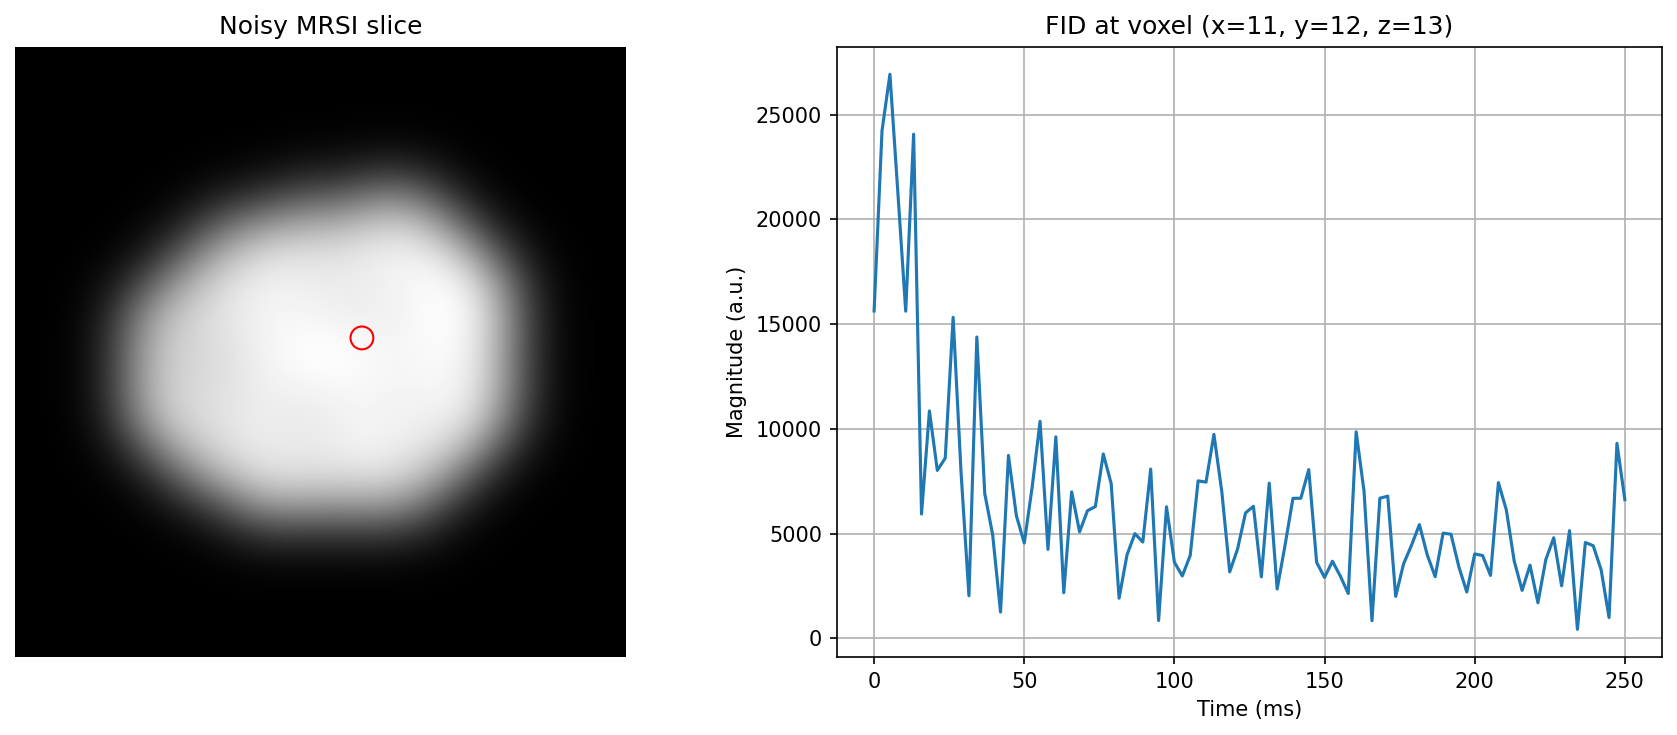

In [ ]:
#Plot 3D alongside FID magnitude.
plot_image_with_FID(vol3d, csi_t, x, y, z, dt, title="Noisy MRSI")


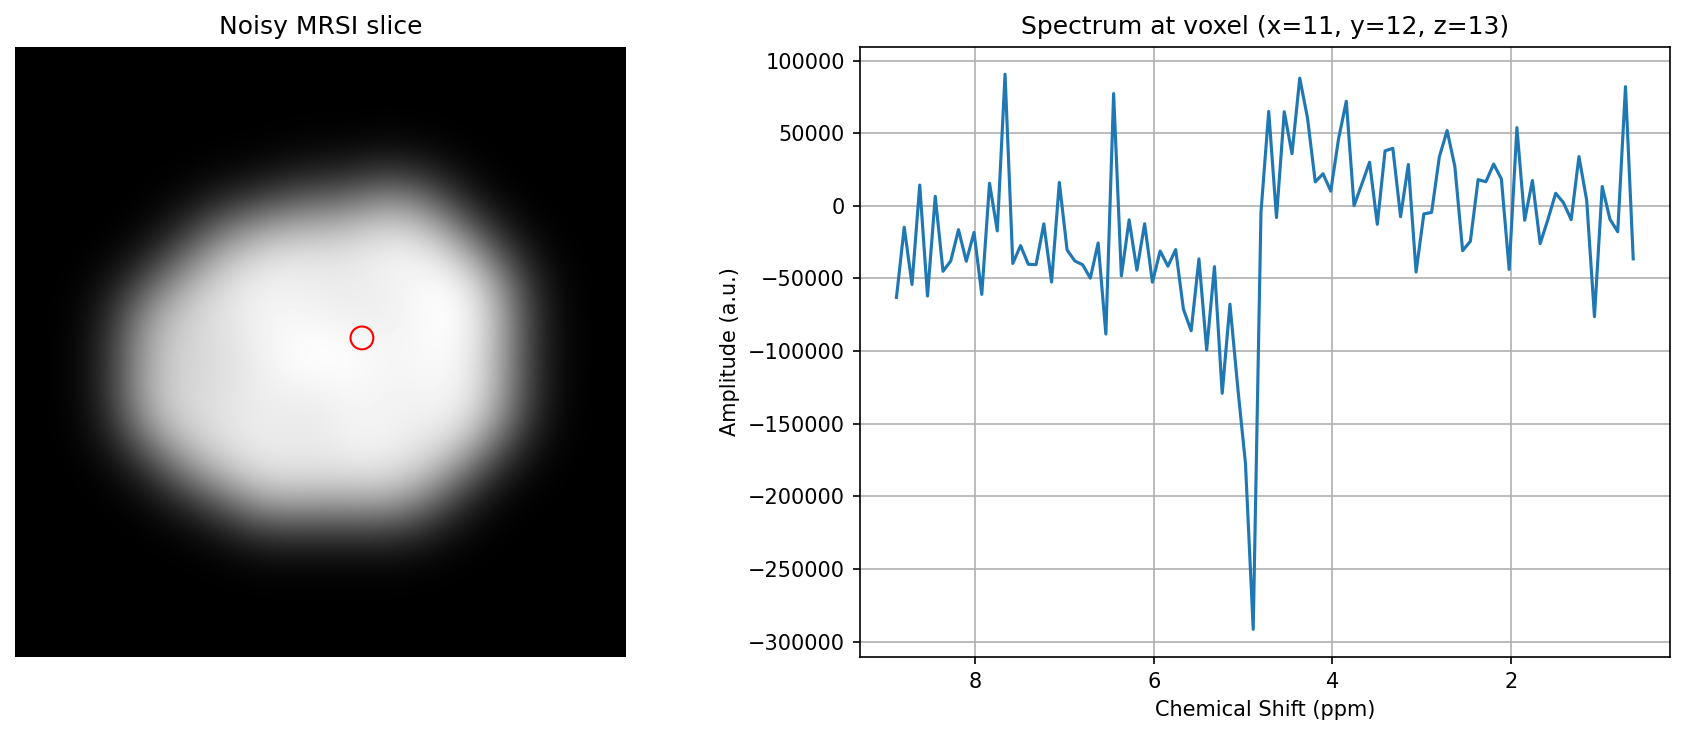

In [ ]:
#Plot 3D plus spectrum in ppm.
plot_image_with_spectrum(vol3d, csi_t, x, y, z, dt, f0, center_ppm, title="Noisy MRSI")


In [ ]:
#Plot full FID image (real +imag)
def plot_image_with_full_FID(vol3d, csi_t, x, y, z, dt, title="MRSI with full FID", phase_idx=0):
    """
    vol3d: 3D structural map [X,Y,Z]
    csi_t: complex CSI tensor [X,Y,Z,T,P]
    x,y,z: voxel coordinates
    dt: dwell time (seconds)
    """

    # prepare structural 2D slice
    img = vol3d[:, :, z].detach().cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    img = nd.gaussian_filter(img, sigma=1.0)

    # extract FID
    FID = csi_t[x, y, z, :, phase_idx].detach().cpu().numpy()

    # time axis in ms
    t = np.arange(len(FID)) * dt * 1e3

    # extract real, imaginary, magnitude
    realFID = np.real(FID)
    imagFID = np.imag(FID)
    magFID  = np.abs(FID)

    # plot
    plt.figure(figsize=(12,5), dpi=150)

    # left panel. 3D slice
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray', origin='lower', interpolation='bicubic')
    plt.scatter(y, x, s=120, facecolors='none', edgecolors='red')
    plt.axis('off')
    plt.title(title + " slice")

    # right panel. FID signals
    plt.subplot(1,2,2)
    plt.plot(t, realFID, label="Real FID")
    plt.plot(t, imagFID, label="Imag FID", alpha=0.8)
    #plt.plot(t, magFID,  label="Magnitude FID", linewidth=2)

    plt.xlabel("Time (ms)")
    plt.ylabel("Signal (a.u.)")
    plt.grid(True)
    plt.title(f"FID at voxel (x={x}, y={y}, z={z})")
    plt.legend()

    plt.tight_layout()
    plt.show()

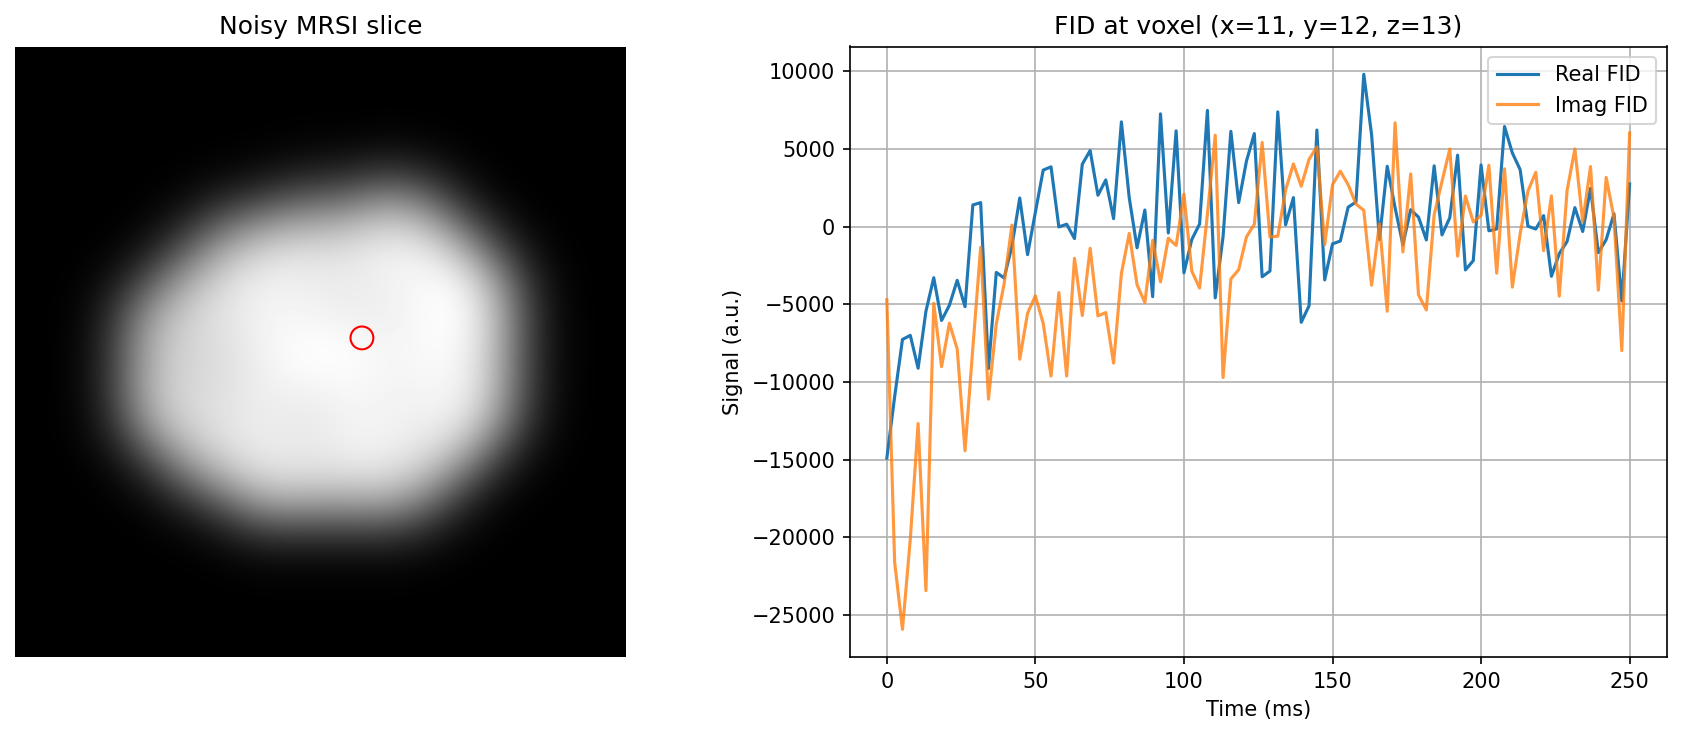

In [ ]:
#Run the plot:
plot_image_with_full_FID(vol3d, csi_t, x, y, z, dt, title="Noisy MRSI", phase_idx=0)

In [ ]:
# Plot full spectrum in ppm (real + imag)
def plot_image_with_full_spectrum_ppm(vol3d, csi_t, x, y, z,
                                      dt, f0, center_ppm=4.8,
                                      title="MRSI with full spectrum",
                                      phase_idx=0):
    """
    vol3d: 3D structural map [X,Y,Z]
    csi_t: complex CSI tensor [X,Y,Z,T,P]
    x,y,z: voxel coordinates
    dt: dwell time (seconds)
    f0: Larmor frequency (Hz)
    center_ppm: reference ppm for center of spectrum
    """

    # structural 2D slice
    img = vol3d[:, :, z].detach().cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    img = nd.gaussian_filter(img, sigma=1.0)

    # FID and spectrum
    FID = csi_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    Spec = np.fft.fftshift(np.fft.fft(FID))

    # ppm axis
    n = Spec.shape[0]
    Fs = 1.0 / dt
    freq_Hz = np.linspace(-Fs/2, Fs/2, n, endpoint=False)
    ppm = center_ppm + freq_Hz * 1e6 / f0

    # components
    realSpec = np.real(Spec)
    imagSpec = np.imag(Spec)
    # magSpec  = np.abs(Spec)

    plt.figure(figsize=(12,5), dpi=150)

    # left panel. 3D slice
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray', origin='lower', interpolation='bicubic')
    plt.scatter(y, x, s=120, facecolors='none', edgecolors='red')
    plt.axis('off')
    plt.title(title + " slice")

    # right panel. spectrum signals
    plt.subplot(1,2,2)
    plt.plot(ppm, realSpec, label="Real spectrum")
    plt.plot(ppm, imagSpec, label="Imag spectrum", alpha=0.8)
    # plt.plot(ppm, magSpec, label="Magnitude spectrum", linewidth=2)

    plt.gca().invert_xaxis()  # NMR convention (high ppm on the left)
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Signal (a.u.)")
    plt.grid(True)
    plt.title(f"Spectrum at voxel (x={x}, y={y}, z={z})")
    plt.legend()

    plt.tight_layout()
    plt.show()

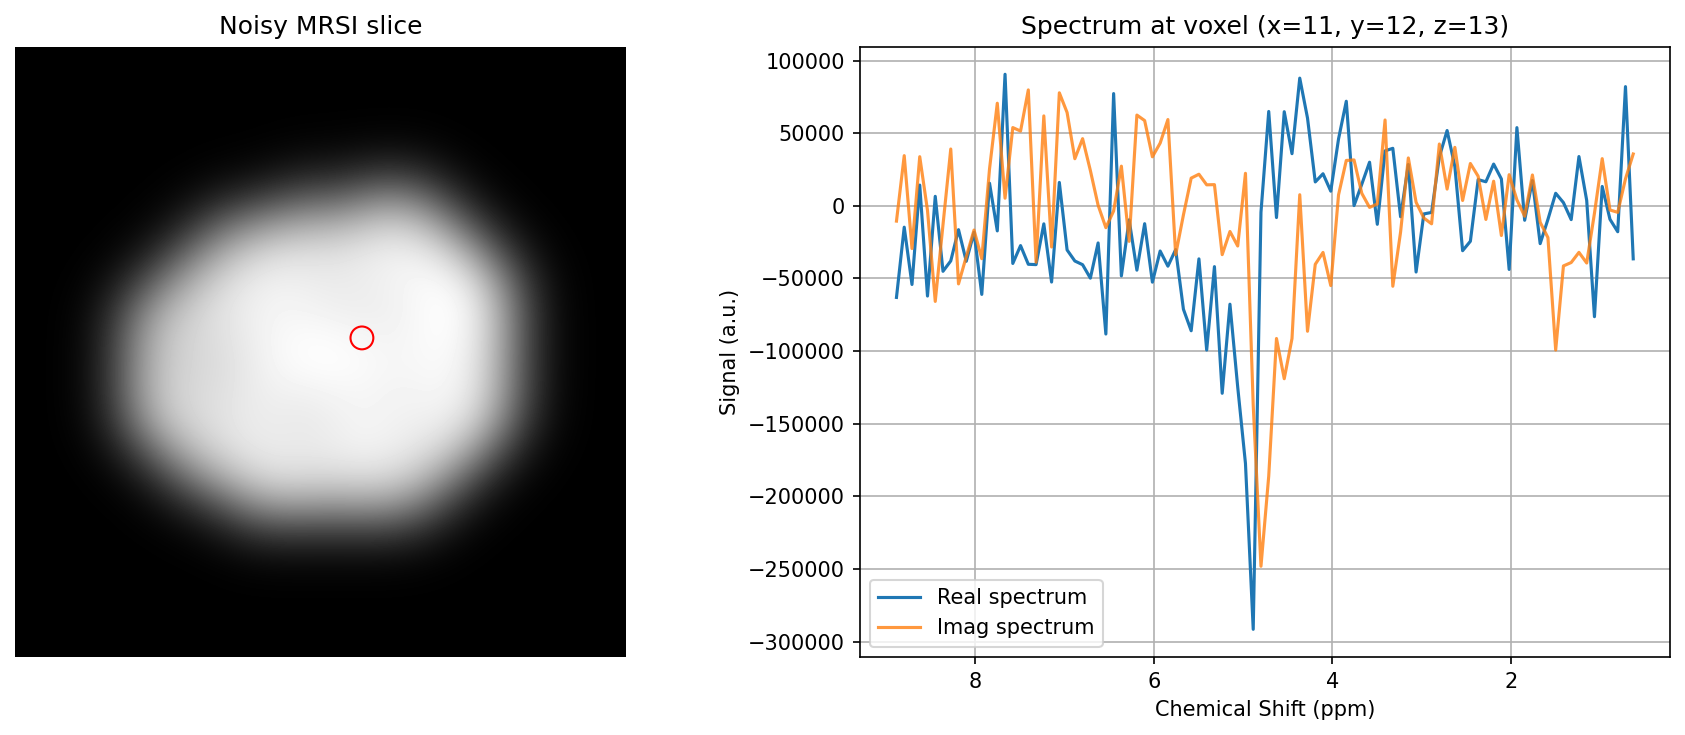

In [ ]:
plot_image_with_full_spectrum_ppm(
    vol3d, csi_t,
    x, y, z,
    dt, f0, center_ppm,
    title="Noisy MRSI",
    phase_idx=0
)


In [ ]:
#Visualize the mask
def plot_mask_slice(mask, z, title="Mask slice"):
    m = mask[:, :, z].detach().cpu().numpy() if isinstance(mask, torch.Tensor) else mask[:, :, z]

    plt.figure(figsize=(4,4), dpi=120)
    plt.imshow(m, cmap="gray", origin="lower")
    plt.title(f"{title} z={z}")
    plt.axis("off")
    plt.show()


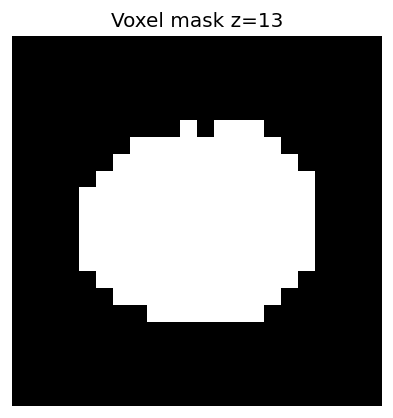

In [ ]:
plot_mask_slice(mask, z=13, title="Voxel mask")


In [ ]:
# Now let's start to separate spatial and spectral data and process individually

In [ ]:
###Step 2 - Spatial data processing ####

In [ ]:
# Function to load spatial data for Noise2Noise
def load_spatial_data(noisy_folder_path, reference_path, exclude_index=None):
    all_noisy_spatial_data = []
    all_reference_data = []
    test_noisy_spatial_data = []
    test_reference_data = []

    # Get all the files
    files = [f for f in os.listdir(noisy_folder_path) if f.endswith('.mat')]

    # If exclude_index is provided, use that file as test data
    if exclude_index is not None:
        test_files = [files[exclude_index]]
        files = [f for i, f in enumerate(files) if i != exclude_index]
    else:
        test_files = []

    # Load training and validation data
    for file_name in files:
        noisy_mat = scipy.io.loadmat(os.path.join(noisy_folder_path, file_name))
        reference_mat = scipy.io.loadmat(os.path.join(reference_path, file_name.replace('_noisy.mat', '_denoised.mat')))

        noisy_csi = noisy_mat['csi']['Data'][0][0]  # shape: (X, Y, Z, Freq, Time)
        reference_csi = reference_mat['csi']['Data'][0][0]

        for f in range(noisy_csi.shape[3]):
            for t in range(noisy_csi.shape[4]):
                noisy_spatial_data = noisy_csi[:, :, :, f, t]
                reference_spatial_data = reference_csi[:, :, :, f, t]

                # Stack real and imag parts into separate channels
                noisy_spatial_data = np.stack([noisy_spatial_data.real, noisy_spatial_data.imag], axis=0)
                reference_spatial_data = np.stack([reference_spatial_data.real, reference_spatial_data.imag], axis=0)

                all_noisy_spatial_data.append(noisy_spatial_data)
                all_reference_data.append(reference_spatial_data)

    # Load test data
    for file_name in test_files:
        noisy_mat = scipy.io.loadmat(os.path.join(noisy_folder_path, file_name))
        reference_mat = scipy.io.loadmat(os.path.join(reference_path, file_name.replace('_noisy.mat', '_denoised.mat')))

        noisy_csi = noisy_mat['csi']['Data'][0][0]
        reference_csi = reference_mat['csi']['Data'][0][0]

        for f in range(noisy_csi.shape[3]):
            for t in range(noisy_csi.shape[4]):
                noisy_spatial_data = noisy_csi[:, :, :, f, t]
                reference_spatial_data = reference_csi[:, :, :, f, t]

                # Stack real and imag parts into separate channels
                noisy_spatial_data = np.stack([noisy_spatial_data.real, noisy_spatial_data.imag], axis=0)
                reference_spatial_data = np.stack([reference_spatial_data.real, reference_spatial_data.imag], axis=0)

                test_noisy_spatial_data.append(noisy_spatial_data)
                test_reference_data.append(reference_spatial_data)

    return np.array(all_noisy_spatial_data), np.array(all_reference_data), np.array(test_noisy_spatial_data), np.array(test_reference_data)

In [ ]:
#Check all loaded data shapes
num_files = len([f for f in os.listdir(noisy_folder_path) if f.endswith('.mat')])

for exclude_index in range(num_files):
    print(f"LOOCV iteration (Spatial): {exclude_index + 1}/{num_files}")
    # Load spatial data for the current exclude_index
    noisy_spatial_data, reference_data, test_noisy_spatial_data, test_reference_data = load_spatial_data(
        noisy_folder_path, reference_path, exclude_index
    )

    # Print shapes to confirm data loading
    print(f"Shape of noisy_spatial_data: {noisy_spatial_data.shape}")
    print(f"Shape of reference_data: {reference_data.shape}")
    print(f"Shape of test_noisy_spatial_data: {test_noisy_spatial_data.shape}")
    print(f"Shape of test_reference_data: {test_reference_data.shape}")


LOOCV iteration (Spatial): 1/6
Shape of noisy_spatial_data: (3840, 2, 22, 22, 21)
Shape of reference_data: (3840, 2, 22, 22, 21)
Shape of test_noisy_spatial_data: (768, 2, 22, 22, 21)
Shape of test_reference_data: (768, 2, 22, 22, 21)
LOOCV iteration (Spatial): 2/6
Shape of noisy_spatial_data: (3840, 2, 22, 22, 21)
Shape of reference_data: (3840, 2, 22, 22, 21)
Shape of test_noisy_spatial_data: (768, 2, 22, 22, 21)
Shape of test_reference_data: (768, 2, 22, 22, 21)
LOOCV iteration (Spatial): 3/6
Shape of noisy_spatial_data: (3840, 2, 22, 22, 21)
Shape of reference_data: (3840, 2, 22, 22, 21)
Shape of test_noisy_spatial_data: (768, 2, 22, 22, 21)
Shape of test_reference_data: (768, 2, 22, 22, 21)
LOOCV iteration (Spatial): 4/6
Shape of noisy_spatial_data: (3840, 2, 22, 22, 21)
Shape of reference_data: (3840, 2, 22, 22, 21)
Shape of test_noisy_spatial_data: (768, 2, 22, 22, 21)
Shape of test_reference_data: (768, 2, 22, 22, 21)
LOOCV iteration (Spatial): 5/6
Shape of noisy_spatial_data: 

In [ ]:
#Define dataset for spatial data
class MRSIDatasetSpatial(Dataset):
    def __init__(self, noisy_data, reference_data=None, augment=False):
        """
        Args:
            noisy_data: The noisy input data.
            reference_data: The reference data, if available.
            augment: Flag to apply augmentation on the data.
        """
        self.noisy_data = noisy_data
        self.reference_data = reference_data  # Optional reference data for secondary target
        self.augment = augment

    def __len__(self):
        return len(self.noisy_data)

    def __getitem__(self, idx):
        noisy_data = torch.tensor(self.noisy_data[idx], dtype=torch.float32)

        # Apply augmentation if specified
        if self.augment:
            noisy_data = self.apply_augmentation(noisy_data)

        # Reference data, if available, for regularization
        reference_data = (
            torch.tensor(self.reference_data[idx], dtype=torch.float32)
            if self.reference_data is not None else None
        )

        return noisy_data, noisy_data, reference_data  # Input, primary target, optional reference

    def apply_augmentation(self, data):
        data = self.add_gaussian_noise(data)
        data = self.intensity_scaling(data)
        data = self.phase_shifting(data)
        data = self.random_erasing(data)
        return data

    def add_gaussian_noise(self, data, mean=0, std=0.01):
        data_np = data.cpu().numpy()  # Convert tensor to NumPy
        noise_real = np.random.normal(mean, std, data_np[0, :, :, :].shape)
        noise_imag = np.random.normal(mean, std, data_np[1, :, :, :].shape)
        data_np[0, :, :, :] += noise_real
        data_np[1, :, :, :] += noise_imag
        return torch.tensor(data_np, dtype=torch.float32).to(data.device)

    def intensity_scaling(self, data, scale_min=0.9, scale_max=1.1):
        scale_factor_real = np.random.uniform(scale_min, scale_max)
        scale_factor_imag = np.random.uniform(scale_min, scale_max)
        data[0, :, :, :] *= scale_factor_real
        data[1, :, :, :] *= scale_factor_imag
        return data

    def phase_shifting(self, data, shift_min=-0.1, shift_max=0.1):
        phase_shift = np.random.uniform(shift_min, shift_max)
        complex_data = data[0, :, :, :] + 1j * data[1, :, :, :]
        shifted_data = complex_data * np.exp(1j * phase_shift)
        data[0, :, :, :] = shifted_data.real
        data[1, :, :, :] = shifted_data.imag
        return data

    def random_erasing(self, data, erase_prob=0.5, erase_value=0):
        if np.random.rand() < erase_prob:
            # Get random spatial coordinates and dimensions for erasing
            c, x, y, z = data.shape
            x_start = np.random.randint(0, x)
            y_start = np.random.randint(0, y)
            z_start = np.random.randint(0, z)
            x_len = np.random.randint(1, x - x_start + 1)
            y_len = np.random.randint(1, y - y_start + 1)
            z_len = np.random.randint(1, z - z_start + 1)
            data[:, x_start:x_start + x_len, y_start:y_start + y_len, z_start:z_start + z_len] = erase_value
        return data

In [ ]:
#Dataset for self-supervised training of spatial data
class Noise2VoidDatasetSpatial(Dataset):
    def __init__(self, noisy_data, reference_data=None, mask_fraction=0.1, augmentation_fn=None):
        """
        Args:
            noisy_data: The noisy input data.
            reference_data: Reference data used for weak supervision, if available.
            mask_fraction: Fraction of voxels to mask for Noise2Void training.
            augmentation_fn: A function to apply augmentation on the data (default is None).
        """
        self.noisy_data = noisy_data
        self.reference_data = reference_data  # Reference data for regularization (optional)
        self.mask_fraction = mask_fraction
        self.augmentation_fn = augmentation_fn  # Optional augmentation function

    def __len__(self):
        return len(self.noisy_data)

    def __getitem__(self, idx):
        noisy_data = self.noisy_data[idx].clone()  # Clone to avoid modifying the original data

        # Apply augmentation if provided
        if self.augmentation_fn is not None:
            noisy_data = self.augmentation_fn(noisy_data)

        # Randomly select voxels to mask
        mask = torch.zeros_like(noisy_data, dtype=torch.bool)
        num_voxels = mask.numel()  # Total number of voxels in the data
        mask_indices = np.random.choice(num_voxels, size=int(self.mask_fraction * num_voxels), replace=False)
        mask.view(-1)[mask_indices] = True  # Apply the mask to random voxels

        masked_data = noisy_data.clone()
        masked_data[mask] = 0  # Set masked regions to 0

        # Load reference data if provided; else set to None
        reference_data = self.reference_data[idx] if self.reference_data is not None else None

        return masked_data, mask, noisy_data, reference_data  # Include reference data in the output

In [ ]:
def normalize_spatial_data(data):
    real_part = data[:, 0, :, :, :]
    imag_part = data[:, 1, :, :, :]

    real_mean, real_std = np.mean(real_part), np.std(real_part)
    imag_mean, imag_std = np.mean(imag_part), np.std(imag_part)

    normalized_real = (real_part - real_mean) / (real_std + 1e-10)
    normalized_imag = (imag_part - imag_mean) / (imag_std + 1e-10)

    normalized_spatial_data = np.stack([normalized_real, normalized_imag], axis=1)
    return normalized_spatial_data, (real_mean, real_std), (imag_mean, imag_std)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define 3D Unet architecture for spatial denoising
class UNet3D_Noise2Void(nn.Module):
    def __init__(self, in_channels, out_channels, mask_ratio=0.1):
        super(UNet3D_Noise2Void, self).__init__()

        self.mask_ratio = mask_ratio  # Fraction of voxels to mask during training

        # Define encoder blocks
        self.enc1 = self.conv_block(in_channels, 32)
        self.enc2 = self.conv_block(32, 64)
        self.enc3 = self.conv_block(64, 128)

        # Define bottleneck
        self.bottleneck = self.conv_block(128, 256)

        # Define decoder blocks
        self.dec3 = self.conv_block(256 + 128, 128)
        self.dec2 = self.conv_block(128 + 64, 64)
        self.dec1 = self.conv_block(64 + 32, 32)

        # Output layer
        self.out = nn.Conv3d(32, out_channels, kernel_size=1)

        # Apply weight initialization
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),  # Batch Normalization
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),  # Batch Normalization
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Apply random masking
        x_masked, mask = self.apply_mask(x)

        # Encoder
        e1 = self.enc1(x_masked)
        e2 = self.enc2(F.max_pool3d(e1, 2))
        e3 = self.enc3(F.max_pool3d(e2, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool3d(e3, 2))

        # Decoder with padding to match dimensions
        d3 = self.dec3(torch.cat([F.interpolate(b, size=e3.shape[2:], mode='trilinear', align_corners=True), e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3, size=e2.shape[2:], mode='trilinear', align_corners=True), e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2, size=e1.shape[2:], mode='trilinear', align_corners=True), e1], dim=1))

        # Output layer
        output = self.out(d1)

        # Return the output and mask
        return output, mask  # Ensure both outputs are returned

    def apply_mask(self, x):
        mask = torch.rand_like(x) < self.mask_ratio  # Create a mask with the defined ratio
        x_masked = x.clone()
        x_masked[mask] = 0  # Mask out selected voxels by setting them to zero
        return x_masked, mask

In [ ]:
# Define SNR based Loss
class SNRLoss(nn.Module):
    def __init__(self):
        super(SNRLoss, self).__init__()

    def forward(self, pred, target):
        pred = pred.float()
        target = target.float()

        signal_power = torch.mean(target ** 2)
        noise_power = torch.mean((target - pred) ** 2)
        snr = signal_power / (noise_power + 1e-10)

        # Minimize 1/SNR
        loss = 1 / snr
        return loss

In [ ]:
# Updated masked_loss_with_regularization function
def masked_loss_with_regularization(output, target, mask, reference):
    """
    Computes the Noise2Void loss with an additional regularization term to encourage the output to
    also learn from the slightly denoised data.

    Parameters:
    - output: The model's output.
    - target: The noisy input target.
    - mask: Mask used for Noise2Void training.
    - reference: Slightly denoised reference data.

    Returns:
    - Combined loss with Noise2Void masking and reference-based regularization.
    """
    snr_loss = SNRLoss()  # Use SNR as a loss function
    mask = mask.float()  # Ensure mask is a float tensor for calculations

    # Noise2Void masked SNR loss
    n2v_loss = snr_loss(output * (1 - mask), target * (1 - mask))

    # Regularization loss with the slightly denoised data
    reference_loss = snr_loss(output, reference)

    # Combine losses, with the regularization weighted (adjust weight as needed)
    combined_loss = n2v_loss + 0.1 * reference_loss
    return combined_loss

In [ ]:
import matplotlib.pyplot as plt

def train_noise2void_with_reference(
    model, train_dataloader, val_dataloader, criterion_train, criterion_val_test, optimizer, num_epochs, name, patience=10
):
    model.to(device)
    epoch_train_losses = []
    epoch_val_losses = []

    # Early stopping variables
    best_val_loss = float('inf')
    no_improvement_count = 0

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for masked_inputs, masks, targets, reference in train_dataloader:
            # Move data to device
            masked_inputs, masks, targets, reference = (
                masked_inputs.to(device),
                masks.to(device),
                targets.to(device),
                reference.to(device),
            )

            optimizer.zero_grad()
            outputs, _ = model(masked_inputs)  # Get model output and mask
            loss = criterion_train(outputs, targets, masks, reference)  # Use modified loss with reference
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * masked_inputs.size(0)

        train_loss = running_loss / len(train_dataloader.dataset)

        # Validation step
        val_loss = validate_spatial(model, val_dataloader, criterion_val_test)

        # Append losses for plotting
        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)

        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')

        # Learning rate scheduler step
        scheduler.step(val_loss)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improvement_count = 0  # Reset the counter if validation loss improves
            # Save the best model
            torch.save(model.state_dict(), f"{name}_best_model.pth")
        else:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                print(f"Early stopping triggered. No improvement for {patience} epochs.")
                break

    # Plot training and validation loss curves
    plt.figure(figsize=(8, 6))
    plt.plot(epoch_train_losses, label='Training Loss')
    plt.plot(epoch_val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{name}_loss_curve.png")  # Save the plot
    plt.show()

    return epoch_train_losses, epoch_val_losses

In [ ]:
def validate_spatial(model, dataloader, criterion_val_test):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets, _ in dataloader:  # Ignore reference if present
            inputs, targets = inputs.to(device), targets.to(device)
            outputs, _ = model(inputs)  # Capture only the output, ignore the mask
            loss = criterion_val_test(outputs, targets)  # Use MSELoss here
            val_loss += loss.item() * inputs.size(0)
    return val_loss / len(dataloader.dataset)


In [ ]:
def test_model_spatial(model, test_dataloader, criterion_val_test):
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets, _ in test_dataloader:  # Ignore reference if present
            inputs, targets = inputs.to(device), targets.to(device)
            outputs, _ = model(inputs)  # Capture only the output, ignore the mask
            loss = criterion_val_test(outputs, targets)  # Use MSELoss for test
            test_loss += loss.item() * inputs.size(0)
    return test_loss / len(test_dataloader.dataset)

In [ ]:
def get_denoised_outputs_spatial(model, test_dataloader):
    model.eval()
    denoised_outputs = []
    with torch.no_grad():
        for inputs, _, _ in test_dataloader:  # Ignore targets and reference
            inputs = inputs.to(device)
            outputs, _ = model(inputs)  # Capture only the output, ignore the mask
            denoised_outputs.append(outputs.cpu().numpy())
    return np.concatenate(denoised_outputs, axis=0)

LOOCV iteration (Spatial): 1/6
Training Noise2Void model with reference


/tmp/ipython-input-243816016.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  noisy_data = torch.tensor(self.noisy_data[idx], dtype=torch.float32)
/tmp/ipython-input-243816016.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.reference_data[idx], dtype=torch.float32)


Epoch 1/50, Train Loss: 0.9694, Validation Loss: 0.8478
Epoch 2/50, Train Loss: 0.6456, Validation Loss: 0.5830
Epoch 3/50, Train Loss: 0.5237, Validation Loss: 0.4434
Epoch 4/50, Train Loss: 0.4323, Validation Loss: 0.3407
Epoch 5/50, Train Loss: 0.3701, Validation Loss: 0.2858
Epoch 6/50, Train Loss: 0.3327, Validation Loss: 0.2668
Epoch 7/50, Train Loss: 0.3054, Validation Loss: 0.2309
Epoch 8/50, Train Loss: 0.2779, Validation Loss: 0.2130
Epoch 9/50, Train Loss: 0.2665, Validation Loss: 0.1934
Epoch 10/50, Train Loss: 0.2466, Validation Loss: 0.1809
Epoch 11/50, Train Loss: 0.2388, Validation Loss: 0.1741
Epoch 12/50, Train Loss: 0.2320, Validation Loss: 0.1584
Epoch 13/50, Train Loss: 0.2215, Validation Loss: 0.1525
Epoch 14/50, Train Loss: 0.2168, Validation Loss: 0.1453
Epoch 15/50, Train Loss: 0.2098, Validation Loss: 0.1439
Epoch 16/50, Train Loss: 0.2107, Validation Loss: 0.1409
Epoch 17/50, Train Loss: 0.2072, Validation Loss: 0.1311
Epoch 18/50, Train Loss: 0.1994, Validat

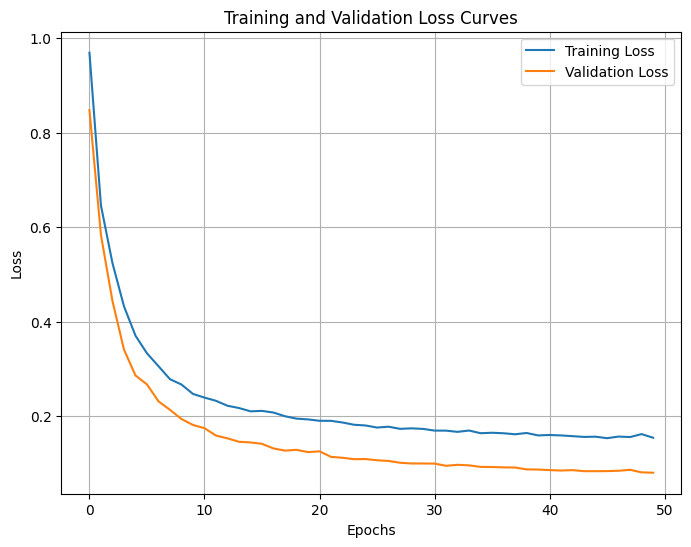

Test Loss for model: 0.0872
LOOCV iteration (Spatial): 2/6
Training Noise2Void model with reference
Epoch 1/50, Train Loss: 1.4762, Validation Loss: 0.8794
Epoch 2/50, Train Loss: 0.8377, Validation Loss: 0.7365
Epoch 3/50, Train Loss: 0.6679, Validation Loss: 0.5897
Epoch 4/50, Train Loss: 0.5433, Validation Loss: 0.4868
Epoch 5/50, Train Loss: 0.4582, Validation Loss: 0.3934
Epoch 6/50, Train Loss: 0.3998, Validation Loss: 0.3198
Epoch 7/50, Train Loss: 0.3607, Validation Loss: 0.2827
Epoch 8/50, Train Loss: 0.3315, Validation Loss: 0.2520
Epoch 9/50, Train Loss: 0.3023, Validation Loss: 0.2373
Epoch 10/50, Train Loss: 0.2852, Validation Loss: 0.2178
Epoch 11/50, Train Loss: 0.2685, Validation Loss: 0.2016
Epoch 12/50, Train Loss: 0.2566, Validation Loss: 0.1917
Epoch 13/50, Train Loss: 0.2477, Validation Loss: 0.1822
Epoch 14/50, Train Loss: 0.2393, Validation Loss: 0.1699
Epoch 15/50, Train Loss: 0.2320, Validation Loss: 0.1690
Epoch 16/50, Train Loss: 0.2240, Validation Loss: 0.15

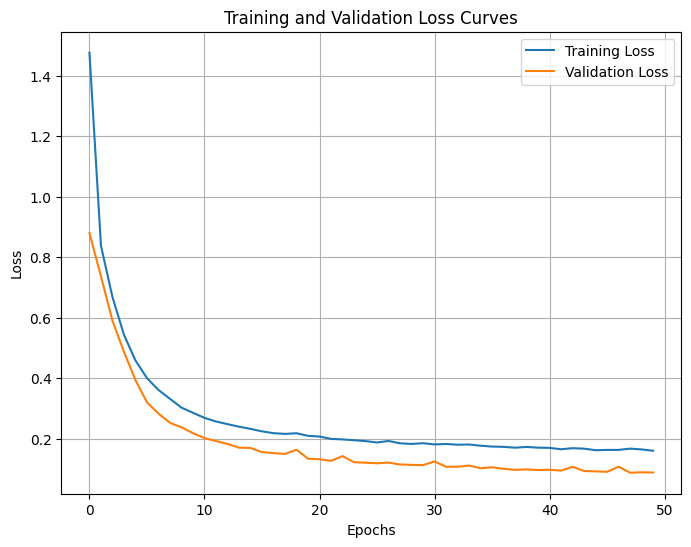

Test Loss for model: 0.0965
LOOCV iteration (Spatial): 3/6
Training Noise2Void model with reference
Epoch 1/50, Train Loss: 1.0211, Validation Loss: 0.8019
Epoch 2/50, Train Loss: 0.6173, Validation Loss: 0.5251
Epoch 3/50, Train Loss: 0.4901, Validation Loss: 0.3873
Epoch 4/50, Train Loss: 0.4133, Validation Loss: 0.3355
Epoch 5/50, Train Loss: 0.3663, Validation Loss: 0.2936
Epoch 6/50, Train Loss: 0.3302, Validation Loss: 0.2559
Epoch 7/50, Train Loss: 0.3066, Validation Loss: 0.2269
Epoch 8/50, Train Loss: 0.2864, Validation Loss: 0.2090
Epoch 9/50, Train Loss: 0.2714, Validation Loss: 0.1963
Epoch 10/50, Train Loss: 0.2611, Validation Loss: 0.1809
Epoch 11/50, Train Loss: 0.2528, Validation Loss: 0.1748
Epoch 12/50, Train Loss: 0.2444, Validation Loss: 0.1646
Epoch 13/50, Train Loss: 0.2408, Validation Loss: 0.1614
Epoch 14/50, Train Loss: 0.2281, Validation Loss: 0.1515
Epoch 15/50, Train Loss: 0.2255, Validation Loss: 0.1557
Epoch 16/50, Train Loss: 0.2164, Validation Loss: 0.14

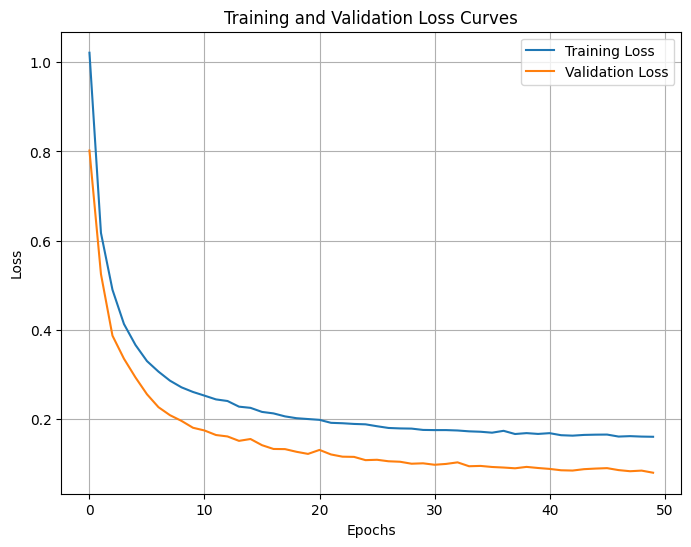

Test Loss for model: 0.0814
LOOCV iteration (Spatial): 4/6
Training Noise2Void model with reference
Epoch 1/50, Train Loss: 0.9990, Validation Loss: 0.7852
Epoch 2/50, Train Loss: 0.6164, Validation Loss: 0.5251
Epoch 3/50, Train Loss: 0.5019, Validation Loss: 0.4097
Epoch 4/50, Train Loss: 0.4266, Validation Loss: 0.3434
Epoch 5/50, Train Loss: 0.3766, Validation Loss: 0.2942
Epoch 6/50, Train Loss: 0.3402, Validation Loss: 0.2566
Epoch 7/50, Train Loss: 0.3124, Validation Loss: 0.2320
Epoch 8/50, Train Loss: 0.2956, Validation Loss: 0.2161
Epoch 9/50, Train Loss: 0.2710, Validation Loss: 0.2025
Epoch 10/50, Train Loss: 0.2589, Validation Loss: 0.1903
Epoch 11/50, Train Loss: 0.2522, Validation Loss: 0.1789
Epoch 12/50, Train Loss: 0.2368, Validation Loss: 0.1633
Epoch 13/50, Train Loss: 0.2294, Validation Loss: 0.1577
Epoch 14/50, Train Loss: 0.2238, Validation Loss: 0.1527
Epoch 15/50, Train Loss: 0.2209, Validation Loss: 0.1447
Epoch 16/50, Train Loss: 0.2146, Validation Loss: 0.14

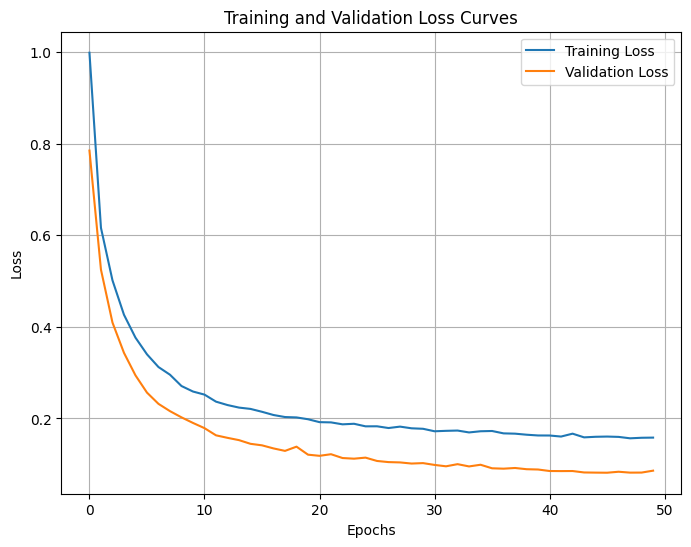

Test Loss for model: 0.0890
LOOCV iteration (Spatial): 5/6
Training Noise2Void model with reference
Epoch 1/50, Train Loss: 1.2125, Validation Loss: 0.7922
Epoch 2/50, Train Loss: 0.7472, Validation Loss: 0.6355
Epoch 3/50, Train Loss: 0.5874, Validation Loss: 0.4960
Epoch 4/50, Train Loss: 0.4770, Validation Loss: 0.3995
Epoch 5/50, Train Loss: 0.4050, Validation Loss: 0.3364
Epoch 6/50, Train Loss: 0.3602, Validation Loss: 0.3006
Epoch 7/50, Train Loss: 0.3346, Validation Loss: 0.2539
Epoch 8/50, Train Loss: 0.3052, Validation Loss: 0.2289
Epoch 9/50, Train Loss: 0.2892, Validation Loss: 0.2091
Epoch 10/50, Train Loss: 0.2697, Validation Loss: 0.1966
Epoch 11/50, Train Loss: 0.2568, Validation Loss: 0.1819
Epoch 12/50, Train Loss: 0.2453, Validation Loss: 0.1782
Epoch 13/50, Train Loss: 0.2387, Validation Loss: 0.1663
Epoch 14/50, Train Loss: 0.2324, Validation Loss: 0.1608
Epoch 15/50, Train Loss: 0.2258, Validation Loss: 0.1524
Epoch 16/50, Train Loss: 0.2181, Validation Loss: 0.14

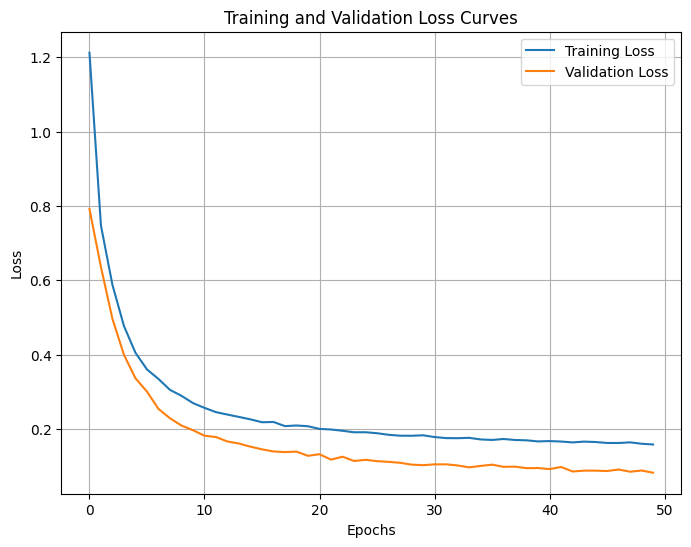

Test Loss for model: 0.0884
LOOCV iteration (Spatial): 6/6
Training Noise2Void model with reference
Epoch 1/50, Train Loss: 1.0468, Validation Loss: 0.8213
Epoch 2/50, Train Loss: 0.6730, Validation Loss: 0.5825
Epoch 3/50, Train Loss: 0.5362, Validation Loss: 0.4286
Epoch 4/50, Train Loss: 0.4420, Validation Loss: 0.3480
Epoch 5/50, Train Loss: 0.3845, Validation Loss: 0.3010
Epoch 6/50, Train Loss: 0.3400, Validation Loss: 0.2619
Epoch 7/50, Train Loss: 0.3179, Validation Loss: 0.2642
Epoch 8/50, Train Loss: 0.2915, Validation Loss: 0.2220
Epoch 9/50, Train Loss: 0.2733, Validation Loss: 0.1971
Epoch 10/50, Train Loss: 0.2689, Validation Loss: 0.1830
Epoch 11/50, Train Loss: 0.2512, Validation Loss: 0.1912
Epoch 12/50, Train Loss: 0.2411, Validation Loss: 0.1651
Epoch 13/50, Train Loss: 0.2325, Validation Loss: 0.1587
Epoch 14/50, Train Loss: 0.2270, Validation Loss: 0.1636
Epoch 15/50, Train Loss: 0.2199, Validation Loss: 0.1453
Epoch 16/50, Train Loss: 0.2136, Validation Loss: 0.14

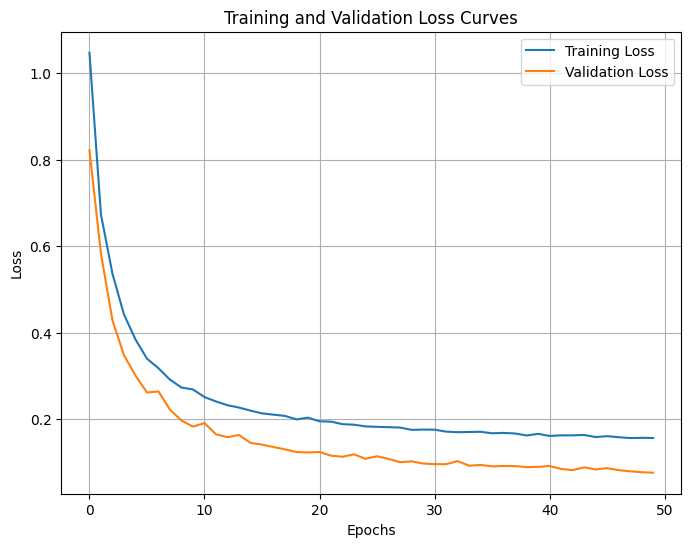

Test Loss for model: 0.0821
Time taken for spatial LOOCV: 7338.09 seconds


In [ ]:
# Initialize lists to store inputs and outputs for spatial data
all_denoised_spatial_outputs = []
all_reference_spatial_data = []
all_noisy_spatial_mean_std_real = []
all_noisy_spatial_mean_std_imag = []
all_spatial_inputs = []

# Initialize lists to accumulate losses for the model
train_losses = []
val_losses = []
test_losses = []

import time

# Start timing
start_time = time.time()

num_files = len([f for f in os.listdir(noisy_folder_path) if f.endswith('.mat')])

# Main LOOCV loop for Noise2Void training with reference data
for exclude_index in range(num_files):
    print(f'LOOCV iteration (Spatial): {exclude_index + 1}/{num_files}')

    # Load noisy and reference spatial data with mask
    noisy_spatial_data, reference_data, test_noisy_spatial_data, test_reference_spatial_data = load_spatial_data(
        noisy_folder_path, reference_path, exclude_index)

    # Normalize the data
    noisy_spatial_data, noisy_spatial_mean_std_real, noisy_spatial_mean_std_imag = normalize_spatial_data(noisy_spatial_data)
    reference_data, _, _ = normalize_spatial_data(reference_data)  # Normalize reference data similarly
    test_noisy_spatial_data, test_noisy_spatial_mean_std_real, test_noisy_spatial_mean_std_imag = normalize_spatial_data(test_noisy_spatial_data)
    test_reference_spatial_data, _, _ = normalize_spatial_data(test_reference_spatial_data)

    # Convert data into tensors
    noisy_spatial_tensor = torch.tensor(noisy_spatial_data, dtype=torch.float32)
    reference_spatial_tensor = torch.tensor(reference_data, dtype=torch.float32)
    test_noisy_spatial_tensor = torch.tensor(test_noisy_spatial_data, dtype=torch.float32)
    test_reference_spatial_tensor = torch.tensor(test_reference_spatial_data, dtype=torch.float32)

    # Split the data into train and validation sets
    X_train, X_val, ref_train, ref_val = train_test_split(noisy_spatial_tensor, reference_spatial_tensor, test_size=0.2, random_state=42)

    batch_size = 256
    num_epochs = 50  # Set the desired number of epochs
    patience = 10  # Set the patience level for early stopping

    # Create Dataloaders
    train_dataset = Noise2VoidDatasetSpatial(X_train, reference_data=ref_train)
    val_dataset = MRSIDatasetSpatial(X_val, reference_data=ref_val)
    test_dataset = MRSIDatasetSpatial(test_noisy_spatial_tensor, reference_data=test_reference_spatial_tensor)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize UNet3D model for Noise2Void with reference
    unet3d_model = UNet3D_Noise2Void(in_channels=2, out_channels=2).to(device)
    criterion_train = masked_loss_with_regularization
    criterion_val_test = SNRLoss()  # MSE for validation and test
    optimizer = torch.optim.Adam(unet3d_model.parameters(), lr=0.0001, weight_decay=0.0001)

    print("Training Noise2Void model with reference")
    train_losses_epoch, val_losses_epoch = train_noise2void_with_reference(
        unet3d_model, train_dataloader, val_dataloader, criterion_train, criterion_val_test, optimizer, num_epochs, f"unet3d_LOOCV_{exclude_index}", patience
    )

    # Test the model on the left-out sample
    test_loss = test_model_spatial(unet3d_model, test_dataloader, criterion_val_test)
    print(f'Test Loss for model: {test_loss:.4f}')

    # Collect the average losses for this iteration
    train_losses.append(np.mean(train_losses_epoch))
    val_losses.append(np.mean(val_losses_epoch))
    test_losses.append(test_loss)

    # Get denoised output for the test set
    denoised_spatial_outputs = get_denoised_outputs_spatial(unet3d_model, test_dataloader)

    # Collect denoised outputs and normalization parameters
    all_denoised_spatial_outputs.append(denoised_spatial_outputs)
    all_noisy_spatial_mean_std_real.append(noisy_spatial_mean_std_real)
    all_noisy_spatial_mean_std_imag.append(noisy_spatial_mean_std_imag)

    # Collect respective inputs
    all_spatial_inputs.append(test_noisy_spatial_data)
    all_reference_spatial_data.append(test_reference_spatial_data)

# End timing
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"Time taken for spatial LOOCV: {elapsed_time:.2f} seconds")


In [ ]:
# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"Time taken for spatial LOOCV: {elapsed_time:.2f} seconds")

Time taken for spatial LOOCV: 7338.09 seconds


In [ ]:
avg_train_loss_UNet = sum(train_losses) / len(train_losses)
avg_val_loss_UNet = sum(val_losses) / len(val_losses)
avg_test_loss_UNet = sum(test_losses) / len(test_losses)

print(f'Average Train Loss (Spatial): {avg_train_loss_UNet:.4f}')
print(f'Average Validation Loss (Spatial): {avg_val_loss_UNet:.4f}')
print(f'Average Test Loss (Spatial): {avg_test_loss_UNet:.4f}')

In [ ]:
# Save the files
save_path = SPATIAL_OUTPUT_DIR

np.save(save_path / 'all_denoised_spatial_outputs.npy', all_denoised_spatial_outputs)
np.save(save_path / 'all_spatial_inputs.npy', all_spatial_inputs)
np.save(save_path / 'all_reference_spatial_data.npy', all_reference_spatial_data)
np.save(save_path / 'all_noisy_spatial_mean_std_real.npy', all_noisy_spatial_mean_std_real)
np.save(save_path / 'all_noisy_spatial_mean_std_imag.npy', all_noisy_spatial_mean_std_imag)

In [ ]:
#load the saved files
# Define the save path where files are located

# Load the saved files
all_denoised_spatial_outputs = np.load(save_path / 'all_denoised_spatial_outputs.npy')
all_spatial_inputs = np.load(save_path / 'all_spatial_inputs.npy')
all_reference_spatial_data = np.load(save_path / 'all_reference_spatial_data.npy')
all_noisy_spatial_mean_std_real = np.load(save_path / 'all_noisy_spatial_mean_std_real.npy')
all_noisy_spatial_mean_std_imag = np.load(save_path / 'all_noisy_spatial_mean_std_imag.npy')

In [ ]:
# Verify by printing shapes or inspecting contents
print("Denoised Spatial Outputs Shape:", all_denoised_spatial_outputs.shape)
print("Spatial Inputs Shape:", all_spatial_inputs.shape)
print("Reference Spatial Data Shape:", all_reference_spatial_data.shape)
print("Noisy Spatial Mean Std Real Shape:", all_noisy_spatial_mean_std_real.shape)
print("Noisy Spatial Mean Std Imag Shape:", all_noisy_spatial_mean_std_imag.shape)

Denoised Spatial Outputs Shape: (6, 768, 2, 22, 22, 21)
Spatial Inputs Shape: (6, 768, 2, 22, 22, 21)
Reference Spatial Data Shape: (6, 768, 2, 22, 22, 21)
Noisy Spatial Mean Std Real Shape: (6, 2)
Noisy Spatial Mean Std Imag Shape: (6, 2)


In [ ]:
#define denormalizing function
def denormalize_spatial_data(denoised_data, mean_std_real, mean_std_imag):
    """
    Denormalizes denoised spatial data using the provided mean and std values for real and imaginary parts.

    Parameters:
    - denoised_data (np.array): Array of denoised outputs of shape [num_samples, num_voxels, 2, depth, height, width].
    - mean_std_real (np.array): Array of shape [num_samples, 2] with (mean, std) for the real part for each sample.
    - mean_std_imag (np.array): Array of shape [num_samples, 2] with (mean, std) for the imaginary part for each sample.

    Returns:
    - denormalized_outputs (np.array): Array of denormalized outputs with the same structure as denoised_data.
    """
    denormalized_spatial_outputs = []

    for i in range(len(denoised_data)):
        # Extract the denoised sample and its corresponding normalization stats
        denoised_sample = denoised_data[i]  # Shape: [768, 2, 22, 22, 21]
        real_mean, real_std = mean_std_real[i]
        imag_mean, imag_std = mean_std_imag[i]

        # Separate the real and imaginary parts
        denoised_real = denoised_sample[:, 0, :, :, :]  # Channel 0 for real part
        denoised_imag = denoised_sample[:, 1, :, :, :]  # Channel 1 for imaginary part

        # Perform denormalization
        denormalized_real = (denoised_real * real_std) + real_mean
        denormalized_imag = (denoised_imag * imag_std) + imag_mean

        # Stack back the real and imaginary parts along the channel axis
        denormalized_sample = np.stack([denormalized_real, denormalized_imag], axis=1)

        # Append to output list
        denormalized_spatial_outputs.append(denormalized_sample)

    return np.array(denormalized_spatial_outputs)

In [ ]:
#denormalize the data
denoised_spatial_denorm = denormalize_spatial_data(all_denoised_spatial_outputs, all_noisy_spatial_mean_std_real,all_noisy_spatial_mean_std_imag)
noisy_spatial_denorm = denormalize_spatial_data(all_spatial_inputs, all_noisy_spatial_mean_std_real, all_noisy_spatial_mean_std_imag)
reference_spatial_denorm = denormalize_spatial_data(all_reference_spatial_data, all_noisy_spatial_mean_std_real, all_noisy_spatial_mean_std_imag)

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr
from joblib import Parallel, delayed

# Define the metrics functions

def psnr_complex_spatial(true, denoised):
    true = np.array(true)
    denoised = np.array(denoised)
    mse_real = np.mean((true[:, :, 0, :, :, :] - denoised[:, :, 0, :, :, :]) ** 2)
    mse_imag = np.mean((true[:, :, 1, :, :, :] - denoised[:, :, 1, :, :, :]) ** 2)
    mse = (mse_real + mse_imag) / 2
    max_value = np.max(true)
    if max_value == 0:
        raise ValueError("Maximum value of true data is zero, cannot compute PSNR.")
    psnr = 20 * np.log10(max_value / np.sqrt(mse))
    return psnr

def ssim_complex_spatial(true, denoised, win_size=3):
    N, S, C, D1, D2, D3 = true.shape
    ssim_total = 0.0
    count = 0
    for n in range(N):
        for s in range(S):
            for c in range(C):
                true_slice = true[n, s, c, :, :, :]
                denoised_slice = denoised[n, s, c, :, :, :]
                min_dim = min(true_slice.shape)
                if min_dim < win_size:
                    raise ValueError(f"win_size={win_size} is too large for image size {true_slice.shape}")
                current_ssim = ssim(
                    true_slice,
                    denoised_slice,
                    data_range=true_slice.max() - true_slice.min(),
                    win_size=win_size,
                    multichannel=False
                )
                ssim_total += current_ssim
                count += 1
    ssim_mean = ssim_total / count
    return ssim_mean

def ssim_complex_spatial_parallel(true, denoised, win_size=3, n_jobs=-1):
    N, S, C, D1, D2, D3 = true.shape
    def compute_ssim(n, s, c):
        true_slice = true[n, s, c, :, :, :]
        denoised_slice = denoised[n, s, c, :, :, :]
        min_dim = min(true_slice.shape)
        if min_dim < win_size:
            raise ValueError(f"win_size={win_size} is too large for image size {true_slice.shape}")
        return ssim(
            true_slice,
            denoised_slice,
            data_range=true_slice.max() - true_slice.min(),
            win_size=win_size,
            multichannel=False
        )
    tasks = [(n, s, c) for n in range(N) for s in range(S) for c in range(C)]
    ssim_scores = Parallel(n_jobs=n_jobs)(
        delayed(compute_ssim)(n, s, c) for n, s, c in tasks
    )
    ssim_mean = np.mean(ssim_scores)
    return ssim_mean

def correlation_complex_spatial(true, denoised):
    true = np.array(true)
    denoised = np.array(denoised)
    true_real = true[:, :, 0, :, :, :].flatten()
    denoised_real = denoised[:, :, 0, :, :, :].flatten()
    true_imag = true[:, :, 1, :, :, :].flatten()
    denoised_imag = denoised[:, :, 1, :, :, :].flatten()
    if np.std(true_real) == 0 or np.std(denoised_real) == 0:
        corr_real = 0
    else:
        corr_real, _ = pearsonr(true_real, denoised_real)
        corr_real = corr_real if not np.isnan(corr_real) else 0
    if np.std(true_imag) == 0 or np.std(denoised_imag) == 0:
        corr_imag = 0
    else:
        corr_imag, _ = pearsonr(true_imag, denoised_imag)
        corr_imag = corr_imag if not np.isnan(corr_imag) else 0
    corr_mean = (corr_real + corr_imag) / 2
    return corr_mean

def correlation_complex_spatial_vectorized(true, denoised):
    true = np.array(true)
    denoised = np.array(denoised)
    N, S, C, D1, D2, D3 = true.shape
    true_reshaped = true.reshape(N * S, C, D1 * D2 * D3)
    denoised_reshaped = denoised.reshape(N * S, C, D1 * D2 * D3)
    correlations = []
    for c in range(C):
        true_channel = true_reshaped[:, c, :]
        denoised_channel = denoised_reshaped[:, c, :]
        true_flat = true_channel.flatten()
        denoised_flat = denoised_channel.flatten()
        if np.std(true_flat) == 0 or np.std(denoised_flat) == 0:
            corr = 0
        else:
            corr, _ = pearsonr(true_flat, denoised_flat)
            corr = corr if not np.isnan(corr) else 0
        correlations.append(corr)
    corr_mean = np.mean(correlations)
    return corr_mean

def calculate_spatial_metrics(true_spatial, denoised_spatial, win_size=3, use_parallel_ssim=False, n_jobs=-1):
    """
    Calculates spatial metrics: PSNR, SSIM, and Correlation.

    Args:
        true_spatial (np.ndarray): Ground truth spatial data, shape [N, S, C, D1, D2, D3]
        denoised_spatial (np.ndarray): Denoised spatial data, shape [N, S, C, D1, D2, D3]
        win_size (int, optional): Window size for SSIM. Defaults to 3.
        use_parallel_ssim (bool, optional): Whether to use parallel processing for SSIM. Defaults to False.
        n_jobs (int, optional): Number of jobs for parallel processing. Defaults to -1.

    Returns:
        dict: Dictionary containing PSNR, SSIM, and Correlation metrics.
    """
    psnr_spatial = psnr_complex_spatial(true_spatial, denoised_spatial)

    if use_parallel_ssim:
        ssim_spatial = ssim_complex_spatial_parallel(true_spatial, denoised_spatial, win_size=win_size, n_jobs=n_jobs)
    else:
        ssim_spatial = ssim_complex_spatial(true_spatial, denoised_spatial, win_size=win_size)

    corr_spatial = correlation_complex_spatial_vectorized(true_spatial, denoised_spatial)

    metrics = {
        'PSNR_Spatial': psnr_spatial,
        'SSIM_Spatial': ssim_spatial,
        'Correlation_Spatial': corr_spatial
    }

    return metrics

In [ ]:
# Calculate spatial metrics
metrics = calculate_spatial_metrics(noisy_spatial_denorm, denoised_spatial_denorm, win_size=3, use_parallel_ssim=False)

# Print each metric on a new line
for key, value in metrics.items():
    print(f'{key}: {value:.4f}')

PSNR_Spatial: 31.1089
SSIM_Spatial: 0.8487
Correlation_Spatial: 0.9564


In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr
from joblib import Parallel, delayed

def psnr_complex_spatial(true, denoised):
    true = np.array(true)
    denoised = np.array(denoised)
    mse_real = np.mean((true[:, 0, :, :, :] - denoised[:, 0, :, :, :]) ** 2)
    mse_imag = np.mean((true[:, 1, :, :, :] - denoised[:, 1, :, :, :]) ** 2)
    mse = (mse_real + mse_imag) / 2
    max_value = np.max(true)
    if max_value == 0:
        raise ValueError("Maximum value of true data is zero, cannot compute PSNR.")
    psnr = 20 * np.log10(max_value / np.sqrt(mse))
    return psnr

def ssim_complex_spatial(true, denoised, win_size=3):
    S, C, D1, D2, D3 = true.shape
    ssim_total = 0.0
    count = 0
    for s in range(S):
        for c in range(C):
            true_slice = true[s, c, :, :, :]
            denoised_slice = denoised[s, c, :, :, :]
            min_dim = min(true_slice.shape)
            if min_dim < win_size:
                raise ValueError(f"win_size={win_size} is too large for image size {true_slice.shape}")
            ssim_sum = 0.0
            slice_count = 0
            for d in range(D3):
                true_2d = true_slice[:, :, d]
                denoised_2d = denoised_slice[:, :, d]
                current_ssim = ssim(
                    true_2d,
                    denoised_2d,
                    data_range=true_2d.max() - true_2d.min(),
                    win_size=win_size
                )
                ssim_sum += current_ssim
                slice_count += 1
            ssim_avg_depth = ssim_sum / slice_count
            ssim_total += ssim_avg_depth
            count += 1
    ssim_mean = ssim_total / count
    return ssim_mean

def ssim_complex_spatial_parallel(true, denoised, win_size=3, n_jobs=-1):
    S, C, D1, D2, D3 = true.shape
    def compute_ssim(s, c):
        true_slice = true[s, c, :, :, :]
        denoised_slice = denoised[s, c, :, :, :]
        min_dim = min(true_slice.shape)
        if min_dim < win_size:
            raise ValueError(f"win_size={win_size} is too large for image size {true_slice.shape}")
        ssim_sum = 0.0
        slice_count = 0
        for d in range(D3):
            true_2d = true_slice[:, :, d]
            denoised_2d = denoised_slice[:, :, d]
            current_ssim = ssim(
                true_2d,
                denoised_2d,
                data_range=true_2d.max() - true_2d.min(),
                win_size=win_size
            )
            ssim_sum += current_ssim
            slice_count += 1
        ssim_avg_depth = ssim_sum / slice_count
        return ssim_avg_depth

    tasks = [(s, c) for s in range(S) for c in range(C)]
    ssim_scores = Parallel(n_jobs=n_jobs)(
        delayed(compute_ssim)(s, c) for s, c in tasks
    )
    ssim_mean = np.mean(ssim_scores)
    return ssim_mean

def correlation_complex_spatial(true, denoised):
    true = np.array(true)
    denoised = np.array(denoised)
    true_real = true[:, 0, :, :, :].flatten()
    denoised_real = denoised[:, 0, :, :, :].flatten()
    true_imag = true[:, 1, :, :, :].flatten()
    denoised_imag = denoised[:, 1, :, :, :].flatten()
    if np.std(true_real) == 0 or np.std(denoised_real) == 0:
        corr_real = 0
    else:
        corr_real, _ = pearsonr(true_real, denoised_real)
        corr_real = corr_real if not np.isnan(corr_real) else 0
    if np.std(true_imag) == 0 or np.std(denoised_imag) == 0:
        corr_imag = 0
    else:
        corr_imag, _ = pearsonr(true_imag, denoised_imag)
        corr_imag = corr_imag if not np.isnan(corr_imag) else 0
    corr_mean = (corr_real + corr_imag) / 2
    return corr_mean

def correlation_complex_spatial_vectorized(true, denoised):
    true = np.array(true)
    denoised = np.array(denoised)
    S, C, D1, D2, D3 = true.shape
    true_reshaped = true.reshape(S, C, D1 * D2 * D3)
    denoised_reshaped = denoised.reshape(S, C, D1 * D2 * D3)
    correlations = []
    for c in range(C):
        true_channel = true_reshaped[:, c, :]
        denoised_channel = denoised_reshaped[:, c, :]
        true_flat = true_channel.flatten()
        denoised_flat = denoised_channel.flatten()
        if np.std(true_flat) == 0 or np.std(denoised_flat) == 0:
            corr = 0
        else:
            corr, _ = pearsonr(true_flat, denoised_flat)
            corr = corr if not np.isnan(corr) else 0
        correlations.append(corr)
    corr_mean = np.mean(correlations)
    return corr_mean

def calculate_spatial_metrics_per_sample(true_spatial, denoised_spatial, win_size=3, use_parallel_ssim=False, n_jobs=-1):
    """
    Calculates spatial metrics: PSNR, SSIM, and Correlation for each sample.

    Args:
        true_spatial (np.ndarray): Ground truth spatial data, shape [N, S, C, D1, D2, D3]
        denoised_spatial (np.ndarray): Denoised spatial data, shape [N, S, C, D1, D2, D3]
        win_size (int, optional): Window size for SSIM. Defaults to 3.
        use_parallel_ssim (bool, optional): Whether to use parallel processing for SSIM. Defaults to False.
        n_jobs (int, optional): Number of jobs for parallel processing. Defaults to -1.

    Returns:
        dict: Dictionary containing PSNR, SSIM, and Correlation metrics for each sample.
    """
    N = true_spatial.shape[0]
    metrics = {}

    for n in range(N):
        true_sample = true_spatial[n]          # Shape: [S, C, D1, D2, D3]
        denoised_sample = denoised_spatial[n]  # Shape: [S, C, D1, D2, D3]

        psnr = psnr_complex_spatial(true_sample, denoised_sample)

        if use_parallel_ssim:
            ssim_val = ssim_complex_spatial_parallel(true_sample, denoised_sample, win_size=win_size, n_jobs=n_jobs)
        else:
            ssim_val = ssim_complex_spatial(true_sample, denoised_sample, win_size=win_size)

        corr = correlation_complex_spatial_vectorized(true_sample, denoised_sample)

        metrics[f'Sample_{n+1}'] = {
            'PSNR_Spatial': psnr,
            'SSIM_Spatial': ssim_val,
            'Correlation_Spatial': corr
        }

    return metrics

In [ ]:
# Calculate spatial metrics for each sample
metrics = calculate_spatial_metrics_per_sample(
    noisy_spatial_denorm,
    denoised_spatial_denorm,
    win_size=3,
    use_parallel_ssim=True,  # Enable parallel processing
    n_jobs=-1                 # Utilize all available CPU cores
)

# Print each metric for each sample on a new line
for sample, metric in metrics.items():
    print(f'{sample}:')
    for key, value in metric.items():
        print(f'  {key}: {value:.4f}')
    print()

Sample_1:
  PSNR_Spatial: 29.0855
  SSIM_Spatial: 0.7611
  Correlation_Spatial: 0.9509

Sample_2:
  PSNR_Spatial: 29.4659
  SSIM_Spatial: 0.7787
  Correlation_Spatial: 0.9571

Sample_3:
  PSNR_Spatial: 28.8107
  SSIM_Spatial: 0.7781
  Correlation_Spatial: 0.9559

Sample_4:
  PSNR_Spatial: 31.5294
  SSIM_Spatial: 0.7811
  Correlation_Spatial: 0.9608

Sample_5:
  PSNR_Spatial: 28.4333
  SSIM_Spatial: 0.7823
  Correlation_Spatial: 0.9580

Sample_6:
  PSNR_Spatial: 30.2315
  SSIM_Spatial: 0.7807
  Correlation_Spatial: 0.9580



In [ ]:
#### Step 3 - Spectral data processing #####

In [ ]:
# Function to load spectral data
def load_spectral_data(noisy_folder_path, reference_path, exclude_index=None):
    all_noisy_spectral_data = []
    all_reference_spectral_data = []
    test_noisy_spectral_data = []
    test_reference_spectral_data = []

    files = [f for f in os.listdir(noisy_folder_path) if f.endswith('.mat')]

    if exclude_index is not None:
        test_files = [files[exclude_index]]
        files = [f for i, f in enumerate(files) if i != exclude_index]
    else:
        test_files = []

    for file_name in files:
        noisy_mat = scipy.io.loadmat(os.path.join(noisy_folder_path, file_name))
        reference_mat = scipy.io.loadmat(os.path.join(reference_path, file_name.replace('_noisy.mat', '_denoised.mat')))

        noisy_csi = noisy_mat['csi']['Data'][0][0]
        reference_csi = reference_mat['csi']['Data'][0][0]

        mask = np.array(noisy_mat['mask']) # if needed
        for x in range(noisy_csi.shape[0]):
            for y in range(noisy_csi.shape[1]):
                for z in range(noisy_csi.shape[2]):
                  #if mask[x, y, z] == 1:
                    noisy_spectral_data = noisy_csi[x, y, z, :, :]
                    reference_spectral_data = reference_csi[x, y, z, :, :]

                    noisy_spectral_data = np.stack([noisy_spectral_data.real, noisy_spectral_data.imag], axis=-1)
                    reference_spectral_data = np.stack([reference_spectral_data.real, reference_spectral_data.imag], axis=-1)

                    all_noisy_spectral_data.append(noisy_spectral_data)
                    all_reference_spectral_data.append(reference_spectral_data)

    for file_name in test_files:
        noisy_mat = scipy.io.loadmat(os.path.join(noisy_folder_path, file_name))
        reference_mat = scipy.io.loadmat(os.path.join(reference_path, file_name.replace('_noisy.mat', '_denoised.mat')))

        noisy_csi = noisy_mat['csi']['Data'][0][0]
        reference_csi = reference_mat['csi']['Data'][0][0]
        mask = np.array(noisy_mat['mask']) # if needed
        for x in range(noisy_csi.shape[0]):
            for y in range(noisy_csi.shape[1]):
                for z in range(noisy_csi.shape[2]):
                  #if mask[x, y, z] == 1:
                    noisy_spectral_data = noisy_csi[x, y, z, :, :]
                    reference_spectral_data = reference_csi[x, y, z, :, :]

                    noisy_spectral_data = np.stack([noisy_spectral_data.real, noisy_spectral_data.imag], axis=-1)
                    reference_spectral_data = np.stack([reference_spectral_data.real, reference_spectral_data.imag], axis=-1)

                    test_noisy_spectral_data.append(noisy_spectral_data)
                    test_reference_spectral_data.append(reference_spectral_data)

    return np.array(all_noisy_spectral_data), np.array(all_reference_spectral_data), np.array(test_noisy_spectral_data), np.array(test_reference_spectral_data)

In [ ]:
num_files = len([f for f in os.listdir(noisy_folder_path) if f.endswith('.mat')])

for exclude_index in range(num_files):
    print(f"LOOCV iteration (Spectral): {exclude_index + 1}/{num_files}")
    # Load spectral data for the current exclude_index
    noisy_spectral_data, reference_spectral_data, test_noisy_spectral_data, test_reference_spectral_data = load_spectral_data(
        noisy_folder_path, reference_path, exclude_index
    )

    # Print shapes to confirm data loading
    print(f"Shape of noisy_spectral_data: {noisy_spectral_data.shape}")
    print(f"Shape of reference_spectral_data: {reference_spectral_data.shape}")
    print(f"Shape of test_noisy_spectral_data: {test_noisy_spectral_data.shape}")
    print(f"Shape of test_reference_spectral_data: {test_reference_spectral_data.shape}")


LOOCV iteration (Spectral): 1/6
Shape of noisy_spectral_data: (50820, 96, 8, 2)
Shape of reference_spectral_data: (50820, 96, 8, 2)
Shape of test_noisy_spectral_data: (10164, 96, 8, 2)
Shape of test_reference_spectral_data: (10164, 96, 8, 2)
LOOCV iteration (Spectral): 2/6
Shape of noisy_spectral_data: (50820, 96, 8, 2)
Shape of reference_spectral_data: (50820, 96, 8, 2)
Shape of test_noisy_spectral_data: (10164, 96, 8, 2)
Shape of test_reference_spectral_data: (10164, 96, 8, 2)
LOOCV iteration (Spectral): 3/6
Shape of noisy_spectral_data: (50820, 96, 8, 2)
Shape of reference_spectral_data: (50820, 96, 8, 2)
Shape of test_noisy_spectral_data: (10164, 96, 8, 2)
Shape of test_reference_spectral_data: (10164, 96, 8, 2)
LOOCV iteration (Spectral): 4/6
Shape of noisy_spectral_data: (50820, 96, 8, 2)
Shape of reference_spectral_data: (50820, 96, 8, 2)
Shape of test_noisy_spectral_data: (10164, 96, 8, 2)
Shape of test_reference_spectral_data: (10164, 96, 8, 2)
LOOCV iteration (Spectral): 5/6


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset

class MRSIDatasetSpectral(Dataset):
    def __init__(self, noisy_data, reference_data=None, augment=False,
                 freq_shift_range=(-2, 2),
                 intensity_scale_range=(0.9, 1.1),
                 phase_shift_range=(-0.1, 0.1),
                 gaussian_noise_std=0.01,
                 erase_prob=0.5,
                 erase_value=0):
        """
        Args:
            noisy_data (np.ndarray): Noisy input data with shape (N, freq_points, temporal_seq, 2)
            reference_data (np.ndarray): Reference data with shape (N, freq_points, temporal_seq, 2)
            augment (bool): Whether to apply data augmentations.
            freq_shift_range (tuple): Range of integers for frequency shifting (circular shift).
            intensity_scale_range (tuple): Range of values for intensity scaling.
            phase_shift_range (tuple): Range of phase shifts in radians.
            gaussian_noise_std (float): Standard deviation of the Gaussian noise to add.
            erase_prob (float): Probability of applying random erasing.
            erase_value (float): Value to fill the erased region with.
        """
        self.noisy_data = noisy_data
        self.reference_data = reference_data
        self.augment = augment
        self.freq_shift_range = freq_shift_range
        self.intensity_scale_range = intensity_scale_range
        self.phase_shift_range = phase_shift_range
        self.gaussian_noise_std = gaussian_noise_std
        self.erase_prob = erase_prob
        self.erase_value = erase_value

    def __len__(self):
        return len(self.noisy_data)

    def __getitem__(self, idx):
        noisy = torch.tensor(self.noisy_data[idx], dtype=torch.float32)
        reference = torch.tensor(self.reference_data[idx], dtype=torch.float32) if self.reference_data is not None else None

        if self.augment and reference is not None:
            noisy, reference = self.apply_augmentations(noisy, reference)

        return noisy, reference

    def apply_augmentations(self, noisy, reference):
        """
        Apply a series of augmentations to both noisy and reference data.
        Some augmentations are applied identically to maintain alignment,
        while others (like adding noise) are applied independently.
        """
        # 1. Frequency Shift (Consistent)
        noisy, reference = self.frequency_shift(noisy, reference)

        # 2. Intensity Scaling (Consistent)
        noisy, reference = self.intensity_scaling(noisy, reference)

        # 3. Phase Shifting (Consistent)
        noisy, reference = self.phase_shifting(noisy, reference)

        # 4. Random Erasing (Consistent)
        noisy, reference = self.random_erasing(noisy, reference)

        # 5. Add Gaussian Noise (Independent)
        noisy = self.add_gaussian_noise(noisy)
        reference = self.add_gaussian_noise(reference) if reference is not None else None

        return noisy, reference

    def frequency_shift(self, noisy, reference):
        """
        Applies a circular frequency shift to both noisy and reference data.
        """
        freq_shift = np.random.randint(self.freq_shift_range[0], self.freq_shift_range[1] + 1)
        if freq_shift != 0:
            noisy = torch.roll(noisy, shifts=freq_shift, dims=1)      # Shift along freq_points dimension
            reference = torch.roll(reference, shifts=freq_shift, dims=1)
        return noisy, reference

    def add_gaussian_noise(self, data, mean=0, std=0.01):
        """
        Adds Gaussian noise to both real and imaginary parts of the data independently.
        """
        if data is None:
            return None
        # Convert to NumPy for noise addition
        data_np = data.cpu().numpy()

        # Add Gaussian noise independently to real and imaginary parts
        noise_real = np.random.normal(mean, std, data_np[:, :, 0].shape)
        noise_imag = np.random.normal(mean, std, data_np[:, :, 1].shape)
        data_np[:, :, 0] += noise_real
        data_np[:, :, 1] += noise_imag

        # Convert back to tensor
        data = torch.tensor(data_np, dtype=torch.float32, device=data.device)

        return data

    def intensity_scaling(self, noisy, reference, scale_min=0.9, scale_max=1.1):
        """
        Randomly scales the intensity of both noisy and reference data.
        """
        scale_factor_real = np.random.uniform(scale_min, scale_max)
        scale_factor_imag = np.random.uniform(scale_min, scale_max)
        noisy[:, :, 0] *= scale_factor_real  # Scale real part
        noisy[:, :, 1] *= scale_factor_imag  # Scale imaginary part

        if reference is not None:
            reference[:, :, 0] *= scale_factor_real
            reference[:, :, 1] *= scale_factor_imag

        return noisy, reference

    def phase_shifting(self, noisy, reference, shift_min=-0.1, shift_max=0.1):
        """
        Applies a global phase shift to both noisy and reference data.
        """
        phase_shift = np.random.uniform(shift_min, shift_max)
        noisy_complex = noisy[:, :, 0] + 1j * noisy[:, :, 1]
        noisy_complex = noisy_complex * np.exp(1j * phase_shift)
        noisy[:, :, 0] = noisy_complex.real
        noisy[:, :, 1] = noisy_complex.imag

        if reference is not None:
            reference_complex = reference[:, :, 0] + 1j * reference[:, :, 1]
            reference_complex = reference_complex * np.exp(1j * phase_shift)
            reference[:, :, 0] = reference_complex.real
            reference[:, :, 1] = reference_complex.imag

        return noisy, reference

    def random_erasing(self, noisy, reference, erase_prob=0.5, erase_value=0):
        """
        Randomly erases a cuboid region in both noisy and reference data.
        """
        if np.random.rand() < erase_prob:
            f, t, c = noisy.shape  # Frequency, temporal, channels
            f_start = np.random.randint(0, f)
            t_start = np.random.randint(0, t)
            f_len = np.random.randint(1, f - f_start + 1)
            t_len = np.random.randint(1, t - t_start + 1)
            noisy[f_start:f_start + f_len, t_start:t_start + t_len, :] = erase_value
            if reference is not None:
                reference[f_start:f_start + f_len, t_start:t_start + t_len, :] = erase_value
        return noisy, reference

In [ ]:
# Define SNR base Loss
class SNRLoss(nn.Module):
    def __init__(self):
        super(SNRLoss, self).__init__()

    def forward(self, pred, target):
        pred = pred.float()
        target = target.float()

        signal_power = torch.mean(target ** 2)
        noise_power = torch.mean((target - pred) ** 2)
        snr = signal_power / (noise_power + 1e-10)

        # Minimize 1/SNR
        loss = 1 / snr
        return loss

In [ ]:
# Validation function
def validate_spectral(model, dataloader, criterion):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    return val_loss / len(dataloader.dataset)

In [ ]:
# Testing function
def test_model_spectral(model, test_dataloader, criterion):
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
    return test_loss / len(test_dataloader.dataset)

In [ ]:
def get_denoised_outputs_spectral(model, test_dataloader):
    model.eval()
    denoised_outputs = []
    with torch.no_grad():
        for inputs, _ in test_dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            denoised_outputs.append(outputs.cpu().numpy())
    return np.concatenate(denoised_outputs, axis=0)

In [ ]:
# Training function for Noise2Noise
def train_model_spectral(model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs, name, patience=10):
    model.to(device)
    epoch_train_losses = []
    epoch_val_losses = []

    best_val_loss = float('inf')
    no_improvement_count = 0

    # Define learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(train_dataloader.dataset)
        val_loss = validate_spectral(model, val_dataloader, criterion)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)

        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Scheduler step
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improvement_count = 0
            torch.save(model.state_dict(), f"{name}_best_model.pth")
        else:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                print(f"Early stopping triggered after {patience} epochs without improvement.")
                break

    return epoch_train_losses, epoch_val_losses

In [ ]:
# Define the Spectral denoising model
import torch
import torch.nn as nn

class SpectralLSTM_Noise2Noise(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout_p=0.1):
        super(SpectralLSTM_Noise2Noise, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Given freq_points=96, channels=2, temporal_seq=8
        # Flattened feature dimension = freq_points * channels = 96*2 = 192
        input_size = 96 * 2
        output_size = input_size  # same shape out as input for consistent reshaping

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout_p)

        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout_fc = nn.Dropout(p=dropout_p)

        # Apply weight initialization
        self._initialize_weights()

    def _initialize_weights(self):
        # Initialize weights and biases for LSTM
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x):
        # x shape: (batch_size, freq_points=96, temporal_seq=8, channels=2)
        batch_size, freq_points, temporal_seq, channels = x.size()

        # Permute to (batch_size, temporal_seq=8, freq_points=96, channels=2)
        x = x.permute(0, 2, 1, 3).contiguous()  # make contiguous for view()

        # Flatten freq_points and channels: (batch_size, 8, 192)
        x = x.view(batch_size, temporal_seq, freq_points * channels)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)

        # LSTM forward pass: (batch_size, temporal_seq=8, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Apply layer normalization
        out = self.layer_norm(out)

        # FC layer: (batch_size, 8, 192)
        out = self.fc(out)

        # Dropout after FC
        out = self.dropout_fc(out)

        # Reshape back to (batch_size, temporal_seq=8, freq_points=96, channels=2)
        out = out.view(batch_size, temporal_seq, freq_points, channels)

        # Permute back to original shape: (batch_size, freq_points=96, temporal_seq=8, channels=2)
        out = out.permute(0, 2, 1, 3)

        return out

In [ ]:
# Function to normalize spectral data
def normalize_spectral_data(train_data, reference_data):
    """
    Normalizes the spectral data based on the training data statistics.

    Args:
        train_data (np.ndarray): Training noisy data with shape (N, freq_points, temporal_seq, 2)
        reference_data (np.ndarray): Training reference data with shape (N, freq_points, temporal_seq, 2)

    Returns:
        tuple: Normalized training data, normalization parameters (mean and std for real and imag parts)
    """
    # Compute mean and std on training data
    real_mean = np.mean(train_data[..., 0])
    real_std = np.std(train_data[..., 0])
    imag_mean = np.mean(train_data[..., 1])
    imag_std = np.std(train_data[..., 1])

    # Normalize training data
    train_data_normalized = np.empty_like(train_data)
    train_data_normalized[..., 0] = (train_data[..., 0] - real_mean) / (real_std + 1e-10)
    train_data_normalized[..., 1] = (train_data[..., 1] - imag_mean) / (imag_std + 1e-10)

    # Normalize reference data using training mean and std
    reference_data_normalized = np.empty_like(reference_data)
    reference_data_normalized[..., 0] = (reference_data[..., 0] - real_mean) / (real_std + 1e-10)
    reference_data_normalized[..., 1] = (reference_data[..., 1] - imag_mean) / (imag_std + 1e-10)

    # Store normalization parameters
    normalization_params = {
        'real_mean': real_mean,
        'real_std': real_std,
        'imag_mean': imag_mean,
        'imag_std': imag_std
    }

    return train_data_normalized, reference_data_normalized, normalization_params


LOOCV iteration (Spectral): 1/6
Training Noise2Noise Spectral LSTM Model


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 0.2548, Val Loss: 0.1429
Epoch 2/50, Train Loss: 0.1481, Val Loss: 0.1063
Epoch 3/50, Train Loss: 0.1284, Val Loss: 0.0933
Epoch 4/50, Train Loss: 0.1199, Val Loss: 0.0865
Epoch 5/50, Train Loss: 0.1148, Val Loss: 0.0818
Epoch 6/50, Train Loss: 0.1112, Val Loss: 0.0783
Epoch 7/50, Train Loss: 0.1083, Val Loss: 0.0755
Epoch 8/50, Train Loss: 0.1060, Val Loss: 0.0738
Epoch 9/50, Train Loss: 0.1042, Val Loss: 0.0713
Epoch 10/50, Train Loss: 0.1027, Val Loss: 0.0694
Epoch 11/50, Train Loss: 0.1010, Val Loss: 0.0686
Epoch 12/50, Train Loss: 0.1001, Val Loss: 0.0672
Epoch 13/50, Train Loss: 0.0990, Val Loss: 0.0662
Epoch 14/50, Train Loss: 0.0980, Val Loss: 0.0651
Epoch 15/50, Train Loss: 0.0973, Val Loss: 0.0645
Epoch 16/50, Train Loss: 0.0966, Val Loss: 0.0642
Epoch 17/50, Train Loss: 0.0961, Val Loss: 0.0627
Epoch 18/50, Train Loss: 0.0956, Val Loss: 0.0625
Epoch 19/50, Train Loss: 0.0950, Val Loss: 0.0620
Epoch 20/50, Train Loss: 0.0947, Val Loss: 0.0617
Epoch 21/

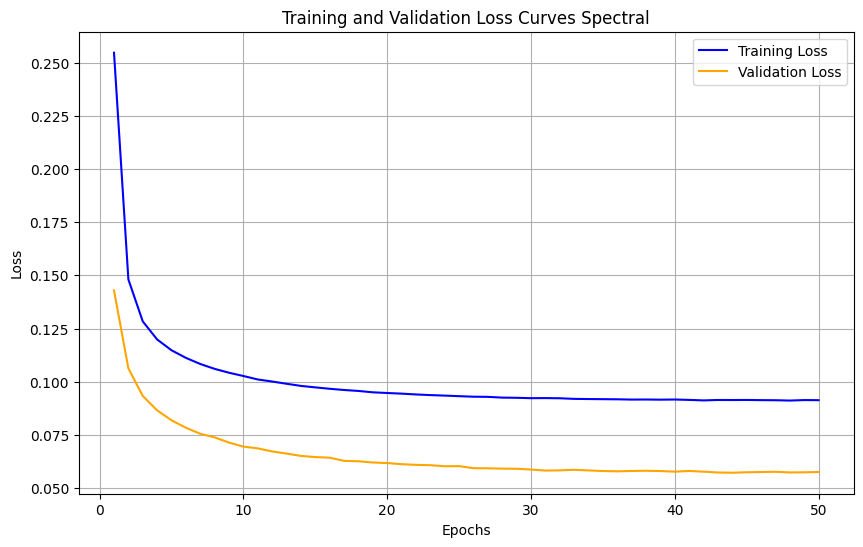

Test Loss (Spectral): 0.0608

LOOCV iteration (Spectral): 2/6
Training Noise2Noise Spectral LSTM Model
Epoch 1/50, Train Loss: 0.2476, Val Loss: 0.1392
Epoch 2/50, Train Loss: 0.1459, Val Loss: 0.1056
Epoch 3/50, Train Loss: 0.1279, Val Loss: 0.0941
Epoch 4/50, Train Loss: 0.1197, Val Loss: 0.0872
Epoch 5/50, Train Loss: 0.1143, Val Loss: 0.0818
Epoch 6/50, Train Loss: 0.1103, Val Loss: 0.0788
Epoch 7/50, Train Loss: 0.1076, Val Loss: 0.0759
Epoch 8/50, Train Loss: 0.1054, Val Loss: 0.0739
Epoch 9/50, Train Loss: 0.1036, Val Loss: 0.0716
Epoch 10/50, Train Loss: 0.1021, Val Loss: 0.0704
Epoch 11/50, Train Loss: 0.1008, Val Loss: 0.0690
Epoch 12/50, Train Loss: 0.0995, Val Loss: 0.0679
Epoch 13/50, Train Loss: 0.0986, Val Loss: 0.0666
Epoch 14/50, Train Loss: 0.0977, Val Loss: 0.0656
Epoch 15/50, Train Loss: 0.0972, Val Loss: 0.0653
Epoch 16/50, Train Loss: 0.0964, Val Loss: 0.0640
Epoch 17/50, Train Loss: 0.0956, Val Loss: 0.0638
Epoch 18/50, Train Loss: 0.0952, Val Loss: 0.0630
Epoch 

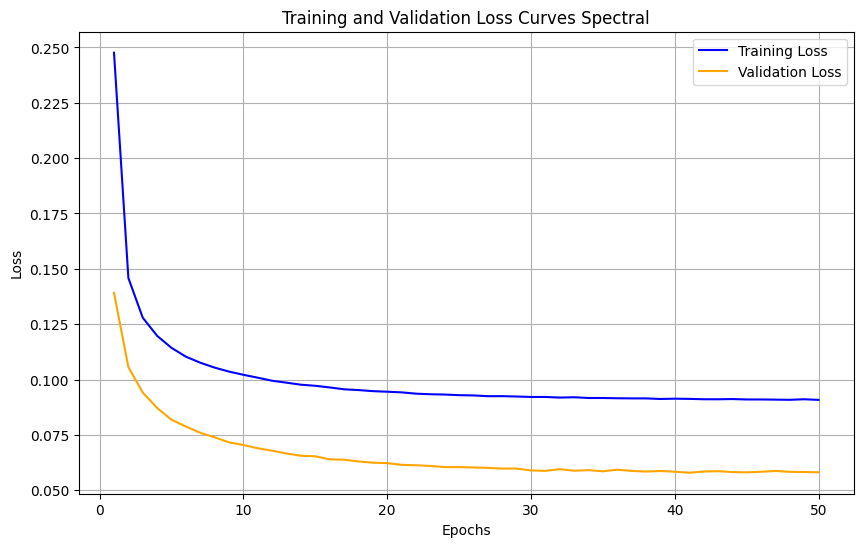

Test Loss (Spectral): 0.0561

LOOCV iteration (Spectral): 3/6
Training Noise2Noise Spectral LSTM Model
Epoch 1/50, Train Loss: 0.2509, Val Loss: 0.1387
Epoch 2/50, Train Loss: 0.1455, Val Loss: 0.1036
Epoch 3/50, Train Loss: 0.1270, Val Loss: 0.0920
Epoch 4/50, Train Loss: 0.1191, Val Loss: 0.0853
Epoch 5/50, Train Loss: 0.1144, Val Loss: 0.0805
Epoch 6/50, Train Loss: 0.1105, Val Loss: 0.0774
Epoch 7/50, Train Loss: 0.1077, Val Loss: 0.0745
Epoch 8/50, Train Loss: 0.1056, Val Loss: 0.0724
Epoch 9/50, Train Loss: 0.1040, Val Loss: 0.0710
Epoch 10/50, Train Loss: 0.1021, Val Loss: 0.0694
Epoch 11/50, Train Loss: 0.1009, Val Loss: 0.0680
Epoch 12/50, Train Loss: 0.0997, Val Loss: 0.0662
Epoch 13/50, Train Loss: 0.0988, Val Loss: 0.0651
Epoch 14/50, Train Loss: 0.0979, Val Loss: 0.0648
Epoch 15/50, Train Loss: 0.0970, Val Loss: 0.0640
Epoch 16/50, Train Loss: 0.0966, Val Loss: 0.0629
Epoch 17/50, Train Loss: 0.0958, Val Loss: 0.0625
Epoch 18/50, Train Loss: 0.0954, Val Loss: 0.0618
Epoch 

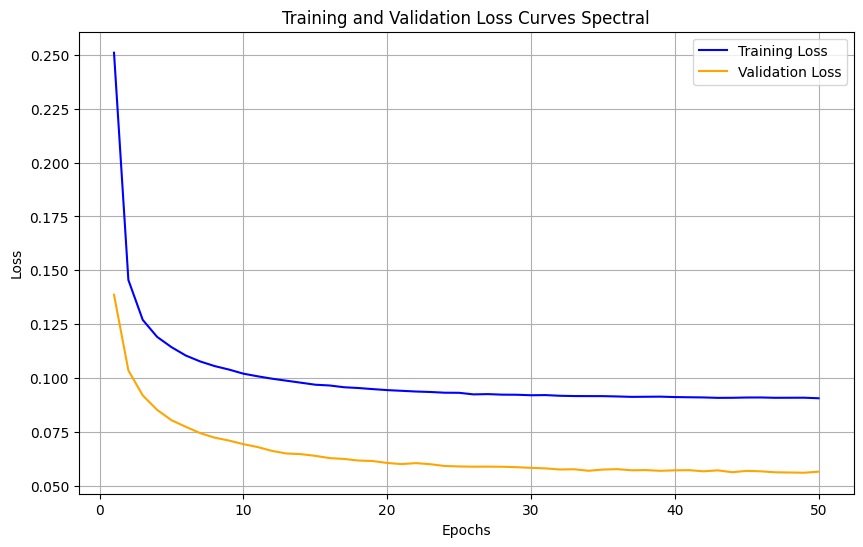

Test Loss (Spectral): 0.0602

LOOCV iteration (Spectral): 4/6
Training Noise2Noise Spectral LSTM Model
Epoch 1/50, Train Loss: 0.2472, Val Loss: 0.1387
Epoch 2/50, Train Loss: 0.1438, Val Loss: 0.1045
Epoch 3/50, Train Loss: 0.1250, Val Loss: 0.0926
Epoch 4/50, Train Loss: 0.1171, Val Loss: 0.0862
Epoch 5/50, Train Loss: 0.1122, Val Loss: 0.0819
Epoch 6/50, Train Loss: 0.1090, Val Loss: 0.0785
Epoch 7/50, Train Loss: 0.1064, Val Loss: 0.0762
Epoch 8/50, Train Loss: 0.1042, Val Loss: 0.0740
Epoch 9/50, Train Loss: 0.1025, Val Loss: 0.0723
Epoch 10/50, Train Loss: 0.1011, Val Loss: 0.0711
Epoch 11/50, Train Loss: 0.0998, Val Loss: 0.0692
Epoch 12/50, Train Loss: 0.0987, Val Loss: 0.0683
Epoch 13/50, Train Loss: 0.0978, Val Loss: 0.0670
Epoch 14/50, Train Loss: 0.0966, Val Loss: 0.0664
Epoch 15/50, Train Loss: 0.0960, Val Loss: 0.0657
Epoch 16/50, Train Loss: 0.0953, Val Loss: 0.0644
Epoch 17/50, Train Loss: 0.0947, Val Loss: 0.0646
Epoch 18/50, Train Loss: 0.0943, Val Loss: 0.0634
Epoch 

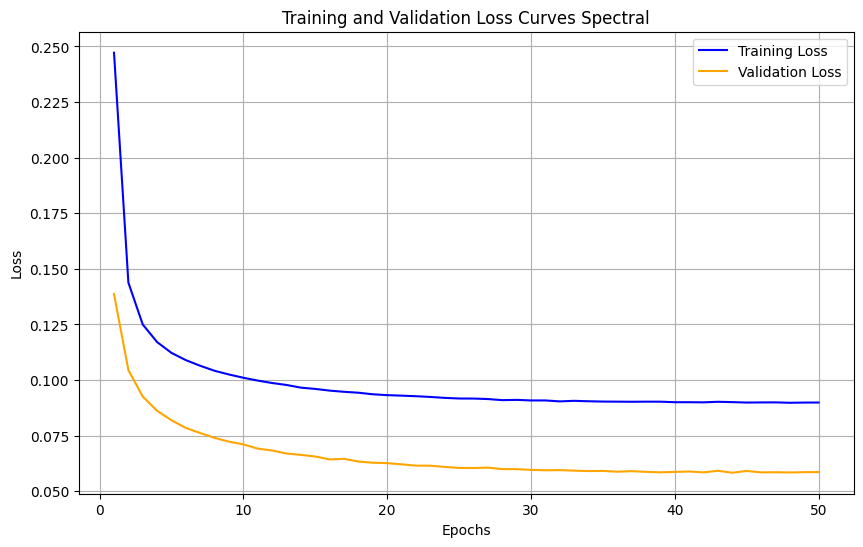

Test Loss (Spectral): 0.0690

LOOCV iteration (Spectral): 5/6
Training Noise2Noise Spectral LSTM Model
Epoch 1/50, Train Loss: 0.2466, Val Loss: 0.1351
Epoch 2/50, Train Loss: 0.1447, Val Loss: 0.1048
Epoch 3/50, Train Loss: 0.1280, Val Loss: 0.0933
Epoch 4/50, Train Loss: 0.1195, Val Loss: 0.0867
Epoch 5/50, Train Loss: 0.1145, Val Loss: 0.0817
Epoch 6/50, Train Loss: 0.1109, Val Loss: 0.0781
Epoch 7/50, Train Loss: 0.1080, Val Loss: 0.0751
Epoch 8/50, Train Loss: 0.1055, Val Loss: 0.0732
Epoch 9/50, Train Loss: 0.1039, Val Loss: 0.0711
Epoch 10/50, Train Loss: 0.1020, Val Loss: 0.0702
Epoch 11/50, Train Loss: 0.1008, Val Loss: 0.0683
Epoch 12/50, Train Loss: 0.0996, Val Loss: 0.0672
Epoch 13/50, Train Loss: 0.0986, Val Loss: 0.0657
Epoch 14/50, Train Loss: 0.0978, Val Loss: 0.0648
Epoch 15/50, Train Loss: 0.0971, Val Loss: 0.0645
Epoch 16/50, Train Loss: 0.0962, Val Loss: 0.0638
Epoch 17/50, Train Loss: 0.0956, Val Loss: 0.0628
Epoch 18/50, Train Loss: 0.0951, Val Loss: 0.0619
Epoch 

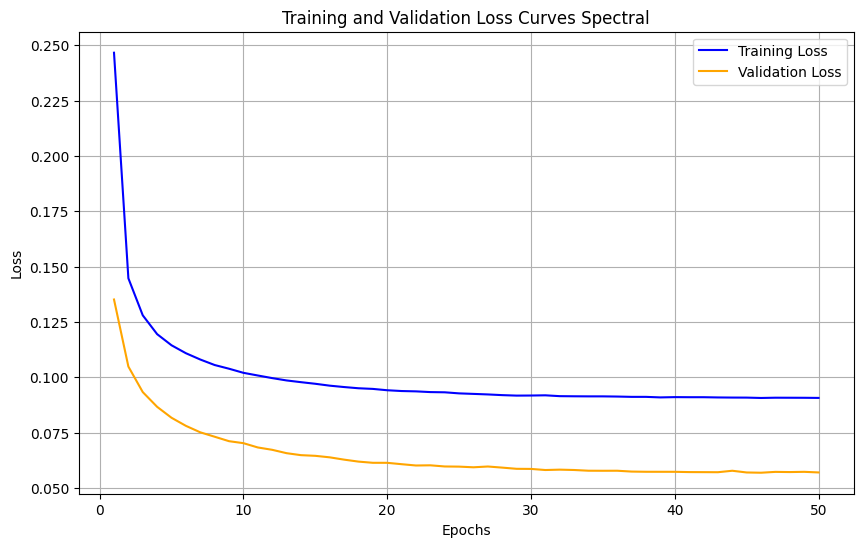

Test Loss (Spectral): 0.0656

LOOCV iteration (Spectral): 6/6
Training Noise2Noise Spectral LSTM Model
Epoch 1/50, Train Loss: 0.2509, Val Loss: 0.1423
Epoch 2/50, Train Loss: 0.1477, Val Loss: 0.1059
Epoch 3/50, Train Loss: 0.1278, Val Loss: 0.0931
Epoch 4/50, Train Loss: 0.1193, Val Loss: 0.0863
Epoch 5/50, Train Loss: 0.1142, Val Loss: 0.0816
Epoch 6/50, Train Loss: 0.1109, Val Loss: 0.0778
Epoch 7/50, Train Loss: 0.1078, Val Loss: 0.0752
Epoch 8/50, Train Loss: 0.1059, Val Loss: 0.0733
Epoch 9/50, Train Loss: 0.1038, Val Loss: 0.0713
Epoch 10/50, Train Loss: 0.1022, Val Loss: 0.0702
Epoch 11/50, Train Loss: 0.1009, Val Loss: 0.0685
Epoch 12/50, Train Loss: 0.0999, Val Loss: 0.0673
Epoch 13/50, Train Loss: 0.0986, Val Loss: 0.0668
Epoch 14/50, Train Loss: 0.0980, Val Loss: 0.0655
Epoch 15/50, Train Loss: 0.0971, Val Loss: 0.0644
Epoch 16/50, Train Loss: 0.0967, Val Loss: 0.0643
Epoch 17/50, Train Loss: 0.0960, Val Loss: 0.0635
Epoch 18/50, Train Loss: 0.0955, Val Loss: 0.0630
Epoch 

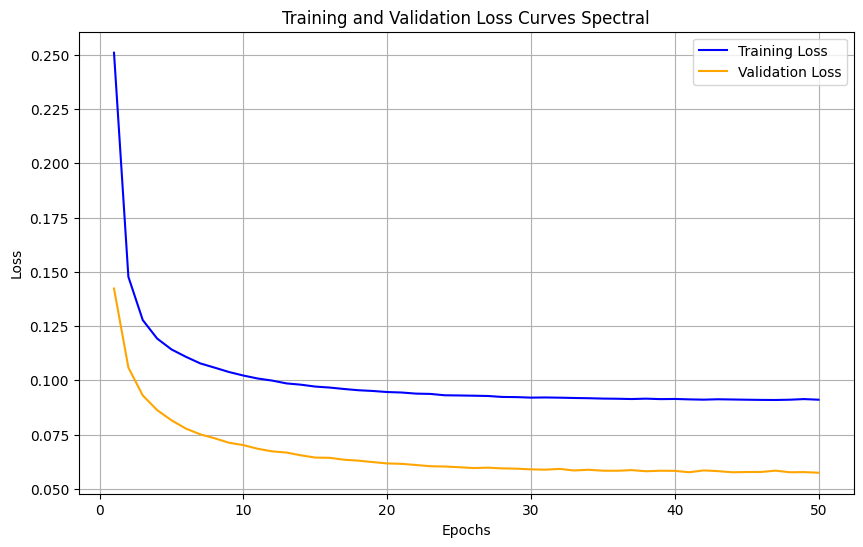

Test Loss (Spectral): 0.0566

Time taken for spectral LOOCV: 8560.60 seconds


In [ ]:
#Mai LOOCV model Training loop

# Initialize lists to store results
all_denoised_spectral_outputs = []
all_reference_spectral_data = []
all_noisy_spectral_mean_std_real = []
all_noisy_spectral_mean_std_imag = []
all_spectral_inputs = []

train_losses_spec = []
val_losses_spec = []
test_losses_spec = []

# Start timing
start_time = time.time()

# Get number of files for LOOCV
num_files = len([f for f in os.listdir(noisy_folder_path) if f.endswith('.mat')])

# LOOCV Loop
for exclude_index in range(num_files):
    print(f'\nLOOCV iteration (Spectral): {exclude_index + 1}/{num_files}')

    # Load data
    noisy_spectral_data, reference_spectral_data, test_noisy_spectral_data, test_reference_spectral_data = load_spectral_data(
        noisy_folder_path, reference_path, exclude_index
    )

    # --------------------------
    # Step 1: Normalize Training Data
    # --------------------------
    train_data_normalized, reference_data_normalized, normalization_params = normalize_spectral_data(noisy_spectral_data, reference_spectral_data)

    # --------------------------
    # Step 2: Normalize Validation and Test Data
    # --------------------------
    test_data_normalized = np.empty_like(test_noisy_spectral_data)
    test_data_normalized[..., 0] = (test_noisy_spectral_data[..., 0] - normalization_params['real_mean']) / (normalization_params['real_std'] + 1e-10)
    test_data_normalized[..., 1] = (test_noisy_spectral_data[..., 1] - normalization_params['imag_mean']) / (normalization_params['imag_std'] + 1e-10)

    test_reference_normalized = np.empty_like(test_reference_spectral_data)
    test_reference_normalized[..., 0] = (test_reference_spectral_data[..., 0] - normalization_params['real_mean']) / (normalization_params['real_std'] + 1e-10)
    test_reference_normalized[..., 1] = (test_reference_spectral_data[..., 1] - normalization_params['imag_mean']) / (normalization_params['imag_std'] + 1e-10)

    # --------------------------
    # Step 3: Split Training Data into Train and Validation Sets
    # --------------------------
    X_train_spec, X_val_spec, ref_train_spec, ref_val_spec = train_test_split(
        train_data_normalized, reference_data_normalized, test_size=0.2, random_state=42
    )

    # --------------------------
    # Step 4: Initialize Datasets
    # --------------------------
    train_dataset_spec = MRSIDatasetSpectral(X_train_spec, ref_train_spec, augment=True)
    val_dataset_spec = MRSIDatasetSpectral(X_val_spec, ref_val_spec, augment=False)
    test_dataset_spec = MRSIDatasetSpectral(test_data_normalized, test_reference_normalized, augment=False)

    # --------------------------
    # Step 5: Initialize DataLoaders
    # --------------------------
    batch_size = 256
    train_dataloader_spec = DataLoader(train_dataset_spec, batch_size=batch_size, shuffle=True)
    val_dataloader_spec = DataLoader(val_dataset_spec, batch_size=batch_size, shuffle=False)
    test_dataloader_spec = DataLoader(test_dataset_spec, batch_size=batch_size, shuffle=False)

    # --------------------------
    # Step 6: Initialize Model
    # --------------------------
    hidden_size = 128
    num_layers = 4
    lstm_model = SpectralLSTM_Noise2Noise(hidden_size, num_layers).to(device)

    # --------------------------
    # Step 7: Define Loss Function and Optimizer
    # --------------------------
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-4, weight_decay=1e-4)

    # --------------------------
    # Step 8: Train the Model
    # --------------------------
    print("Training Noise2Noise Spectral LSTM Model")
    train_losses_spec_epoch, val_losses_spec_epoch = train_model_spectral(
        lstm_model, train_dataloader_spec, val_dataloader_spec, criterion, optimizer, num_epochs=50, name=f"lstm_spectral_{exclude_index}", patience=10
    )

    # Plot training curves for this LOOCV iteration
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses_spec_epoch) + 1), train_losses_spec_epoch, label='Training Loss', color='blue')
    plt.plot(range(1, len(val_losses_spec_epoch) + 1), val_losses_spec_epoch, label='Validation Loss', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training and Validation Loss Curves Spectral')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"training_curve_loocv_{exclude_index + 1}.png")
    plt.show()

    # --------------------------
    # Step 9: Test the Model
    # --------------------------
    test_loss = test_model_spectral(lstm_model, test_dataloader_spec, criterion)
    print(f'Test Loss (Spectral): {test_loss:.4f}')

    # --------------------------
    # Step 10: Record Losses
    # --------------------------
    train_losses_spec.append(np.mean(train_losses_spec_epoch))
    val_losses_spec.append(np.mean(val_losses_spec_epoch))
    test_losses_spec.append(test_loss)

    # --------------------------
    # Step 11: Get Denoised Outputs
    # --------------------------
    denoised_spectral_outputs = get_denoised_outputs_spectral(lstm_model, test_dataloader_spec)

    # --------------------------
    # Step 12: Append Results to Lists
    # --------------------------
    all_denoised_spectral_outputs.append(denoised_spectral_outputs)
    all_reference_spectral_data.append(test_reference_normalized)
    all_noisy_spectral_mean_std_real.append((normalization_params['real_mean'], normalization_params['real_std']))
    all_noisy_spectral_mean_std_imag.append((normalization_params['imag_mean'], normalization_params['imag_std']))
    all_spectral_inputs.append(test_data_normalized)

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTime taken for spectral LOOCV: {elapsed_time:.2f} seconds")

In [ ]:
# Calculate and print the average losses over all iterations
avg_train_loss_spec = sum(train_losses_spec) / len(train_losses_spec)
avg_val_loss_spec = sum(val_losses_spec) / len(val_losses_spec)
avg_test_loss_spec = sum(test_losses_spec) / len(test_losses_spec)

print(f'Average Train Loss for Spectral model: {avg_train_loss_spec:.4f}')
print(f'Average Validation Loss for Spectral model: {avg_val_loss_spec:.4f}')
print(f'Average Test Loss for Spectral model: {avg_test_loss_spec:.4f}')

Average Train Loss for Spectral model: 0.1001
Average Validation Loss for Spectral model: 0.0656
Average Test Loss for Spectral model: 0.0614


In [ ]:
# Save the files
save_path_spec = SPECTRAL_OUTPUT_DIR
np.save(save_path_spec / 'denoised_spectral_outputs.npy', all_denoised_spectral_outputs)
np.save(save_path_spec / 'spectral_inputs.npy', all_spectral_inputs)
np.save(save_path_spec / 'reference_spectral_data.npy', all_reference_spectral_data)
np.save(save_path_spec / 'noisy_spectral_mean_std_real.npy', all_noisy_spectral_mean_std_real)
np.save(save_path_spec / 'noisy_spectral_mean_std_imag.npy', all_noisy_spectral_mean_std_imag)

In [ ]:
#load the saved spectral files
# Define the save path where files are located

# Load the saved files
denoised_spectral_outputs = np.load(save_path_spec / 'denoised_spectral_outputs.npy')
spectral_inputs = np.load(save_path_spec / 'spectral_inputs.npy')
reference_spectral_data = np.load(save_path_spec / 'reference_spectral_data.npy')
noisy_spectral_mean_std_real = np.load(save_path_spec / 'noisy_spectral_mean_std_real.npy')
noisy_spectral_mean_std_imag = np.load(save_path_spec / 'noisy_spectral_mean_std_imag.npy')

In [ ]:
# Verify by printing shapes or inspecting contents for spectral data
print("Denoised Spectral Outputs Shape:", denoised_spectral_outputs.shape)
print("Spectral Inputs Shape:", spectral_inputs.shape)
print("Reference Spectral Data Shape:", reference_spectral_data.shape)
print("Noisy Spectral Mean Std Real Shape:", noisy_spectral_mean_std_real.shape)
print("Noisy Spectral Mean Std Imag Shape:", noisy_spectral_mean_std_imag.shape)

Denoised Spectral Outputs Shape: (6, 10164, 96, 8, 2)
Spectral Inputs Shape: (6, 10164, 96, 8, 2)
Reference Spectral Data Shape: (6, 10164, 96, 8, 2)
Noisy Spectral Mean Std Real Shape: (6, 2)
Noisy Spectral Mean Std Imag Shape: (6, 2)


In [ ]:
def denormalize_spectral(denoised_data, mean_std_real, mean_std_imag):
    """
    Denormalizes spectral data for each sample using its own mean and std values for real and imaginary parts.

    Parameters:
    - denoised_data (np.array): Array of denoised spectral data with shape [6, 10164, 96, 8, 2].
    - mean_std_real (np.array): Array with shape [6, 2] containing (mean, std) for the real part for each sample.
    - mean_std_imag (np.array): Array with shape [6, 2] containing (mean, std) for the imaginary part for each sample.

    Returns:
    - denormalized_outputs (np.array): Array of denormalized spectral data with the same shape as denoised_data.
    """
    denormalized_outputs = []

    for i in range(len(denoised_data)):
        # Extract the data and mean/std values for each sample
        sample_data = denoised_data[i]
        real_mean, real_std = mean_std_real[i]
        imag_mean, imag_std = mean_std_imag[i]

        # Separate real and imaginary parts
        denoised_real = sample_data[..., 0]
        denoised_imag = sample_data[..., 1]

        # Denormalize
        denormalized_real = (denoised_real * real_std) + real_mean
        denormalized_imag = (denoised_imag * imag_std) + imag_mean

        # Stack back together
        denormalized_sample = np.stack([denormalized_real, denormalized_imag], axis=-1)
        denormalized_outputs.append(denormalized_sample)

    return np.array(denormalized_outputs)

In [ ]:
# Denormalize spectral data
spectral_outputs_denorm = denormalize_spectral(denoised_spectral_outputs, noisy_spectral_mean_std_real, noisy_spectral_mean_std_imag)
spectral_inputs_denorm = denormalize_spectral(spectral_inputs, noisy_spectral_mean_std_real, noisy_spectral_mean_std_imag)
spectral_reference_denorm = denormalize_spectral(reference_spectral_data, noisy_spectral_mean_std_real, noisy_spectral_mean_std_imag)

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr

def psnr_spectral(true, denoised):
    mse_real = np.mean((true[..., 0] - denoised[..., 0]) ** 2)
    mse_imag = np.mean((true[..., 1] - denoised[..., 1]) ** 2)
    mse = (mse_real + mse_imag) / 2
    max_val = np.max(true)
    psnr = 20 * np.log10(max_val / np.sqrt(mse)) if mse != 0 else float('inf')
    return psnr

def ssim_spectral(true, denoised):
    true_real = true[..., 0].reshape(-1, true.shape[-2])
    denoised_real = denoised[..., 0].reshape(-1, denoised.shape[-2])
    true_imag = true[..., 1].reshape(-1, true.shape[-2])
    denoised_imag = denoised[..., 1].reshape(-1, denoised.shape[-2])

    ssim_real = ssim(
        true_real, denoised_real,
        data_range=true_real.max() - true_real.min()
    )
    ssim_imag = ssim(
        true_imag, denoised_imag,
        data_range=true_imag.max() - true_imag.min()
    )
    return (ssim_real + ssim_imag) / 2

def correlation_spectral(true, denoised):
    true_real = true[..., 0].flatten()
    denoised_real = denoised[..., 0].flatten()
    true_imag = true[..., 1].flatten()
    denoised_imag = denoised[..., 1].flatten()

    corr_real, _ = pearsonr(true_real, denoised_real)
    corr_imag, _ = pearsonr(true_imag, denoised_imag)
    return (corr_real + corr_imag) / 2

In [ ]:
# Evaluate metrics for each sample
metrics = []
for i in range(spectral_outputs_denorm.shape[0]):
    psnr_val = psnr_spectral(spectral_reference_denorm[i], spectral_outputs_denorm[i])
    ssim_val = ssim_spectral(spectral_reference_denorm[i], spectral_outputs_denorm[i])
    corr_val = correlation_spectral(spectral_reference_denorm[i], spectral_outputs_denorm[i])
    metrics.append((i+1, psnr_val, ssim_val, corr_val))

# Print results
for m in metrics:
    print(f"Sample {m[0]} - PSNR: {m[1]:.4f}, SSIM: {m[2]:.4f}, Correlation: {m[3]:.4f}")

Sample 1 - PSNR: 29.8714, SSIM: 0.7427, Correlation: 0.9076
Sample 2 - PSNR: 30.2305, SSIM: 0.8048, Correlation: 0.9278
Sample 3 - PSNR: 28.7930, SSIM: 0.7661, Correlation: 0.9016
Sample 4 - PSNR: 31.8215, SSIM: 0.8332, Correlation: 0.9361
Sample 5 - PSNR: 28.3858, SSIM: 0.7547, Correlation: 0.9139
Sample 6 - PSNR: 30.9629, SSIM: 0.7854, Correlation: 0.9245


In [ ]:
import numpy as np

# Assuming 'metrics' is a list of tuples: (sample_index, psnr, ssim, correlation)
# Example: metrics = [(1, 32.1, 0.91, 0.98), (2, 31.9, 0.90, 0.97), ...]

# Convert to NumPy array for easy slicing
metrics_array = np.array(metrics)

# Compute averages (columns 1: PSNR, 2: SSIM, 3: Correlation)
avg_psnr = np.mean(metrics_array[:, 1])
avg_ssim = np.mean(metrics_array[:, 2])
avg_corr = np.mean(metrics_array[:, 3])

# Print average metrics
print(f"Average PSNR: {avg_psnr:.4f}")
print(f"Average SSIM: {avg_ssim:.4f}")
print(f"Average Correlation: {avg_corr:.4f}")

Average PSNR: 30.0108
Average SSIM: 0.7812
Average Correlation: 0.9186


In [ ]:
# Evaluate and compare metrics for low rank denoised data
metrics = []
for i in range(spectral_outputs_denorm.shape[0]):
    psnr_val = psnr_spectral(spectral_inputs_denorm[i], spectral_reference_denorm[i])
    ssim_val = ssim_spectral(spectral_inputs_denorm[i], spectral_reference_denorm[i])
    corr_val = correlation_spectral(spectral_inputs_denorm[i], spectral_reference_denorm[i])
    metrics.append((i+1, psnr_val, ssim_val, corr_val))

# Print results
for m in metrics:
    print(f"Sample {m[0]} - PSNR: {m[1]:.4f}, SSIM: {m[2]:.4f}, Correlation: {m[3]:.4f}")

Sample 1 - PSNR: 20.5741, SSIM: 0.3157, Correlation: 0.5809
Sample 2 - PSNR: 20.9261, SSIM: 0.3607, Correlation: 0.6177
Sample 3 - PSNR: 19.8585, SSIM: 0.3229, Correlation: 0.5718
Sample 4 - PSNR: 22.9579, SSIM: 0.4328, Correlation: 0.6617
Sample 5 - PSNR: 19.7313, SSIM: 0.3476, Correlation: 0.6010
Sample 6 - PSNR: 21.3835, SSIM: 0.3356, Correlation: 0.6106


In [ ]:
### Now we have both spatially and spectrally denoised data ###

In [ ]:
### Step 4 - Reconstruct original 5D MRSI data

In [ ]:
def reconstruct_original_data(denoised_spatial_outputs, denoised_spectral_outputs):
    """
    Reconstructs the original complex data shape [22, 22, 21, 96, 8]
    from separate spatial and spectral denoised data.

    Parameters:
    - denoised_spatial_outputs: Array of denoised spatial outputs with shape [6, 768, 2, 22, 22, 21].
    - denoised_spectral_outputs: Array of denoised spectral outputs with shape [6, 10164, 96, 8, 2].

    Returns:
    - reconstructed_data: Reconstructed complex data with shape [6, 22, 22, 21, 96, 8].
    """
    reconstructed_samples = []

    for spatial_data, spectral_data in zip(denoised_spatial_outputs, denoised_spectral_outputs):
        # Prepare arrays for real and imaginary parts with shape [22, 22, 21, 96, 8]
        real_part = np.zeros((22, 22, 21, 96, 8))
        imag_part = np.zeros((22, 22, 21, 96, 8))

        # Fill real and imaginary parts using the spatial data
        for idx in range(768):  # 768 = 96 * 8
            f = idx // 8  # Frequency index (0 to 95)
            t = idx % 8   # Temporal index (0 to 7)
            real_part[..., f, t] = spatial_data[idx, 0, ...]
            imag_part[..., f, t] = spatial_data[idx, 1, ...]

        # Integrate the spectral data by filling real and imaginary parts at voxel level
        for voxel in range(10164):  # 10164 = 22 * 22 * 21
            x = voxel // (22 * 21)
            y = (voxel % (22 * 21)) // 21
            z = voxel % 21
            real_part[x, y, z, :, :] = spectral_data[voxel, :, :, 0]
            imag_part[x, y, z, :, :] = spectral_data[voxel, :, :, 1]

        # Combine real and imaginary parts into a complex data array
        reconstructed_complex = real_part + 1j * imag_part
        reconstructed_samples.append(reconstructed_complex)

    return np.array(reconstructed_samples)

In [ ]:
# recall and denormalize spatiall data
denoised_spatial_denorm = denormalize_spatial_data(all_denoised_spatial_outputs, all_noisy_spatial_mean_std_real,all_noisy_spatial_mean_std_imag)
noisy_spatial_denorm = denormalize_spatial_data(all_spatial_inputs, all_noisy_spatial_mean_std_real, all_noisy_spatial_mean_std_imag)
reference_spatial_denorm = denormalize_spatial_data(all_reference_spatial_data, all_noisy_spatial_mean_std_real, all_noisy_spatial_mean_std_imag)

In [ ]:
print('shape denoised', denoised_spatial_denorm.shape)
print('shape noisy', noisy_spatial_denorm .shape)
print('shape ref', reference_spatial_denorm.shape)

shape denoised (6, 768, 2, 22, 22, 21)
shape noisy (6, 768, 2, 22, 22, 21)
shape ref (6, 768, 2, 22, 22, 21)


In [ ]:
# Denormalize spectral data
spectral_outputs_denorm = denormalize_spectral(denoised_spectral_outputs, noisy_spectral_mean_std_real, noisy_spectral_mean_std_imag)
spectral_inputs_denorm = denormalize_spectral(spectral_inputs, noisy_spectral_mean_std_real, noisy_spectral_mean_std_imag)
spectral_reference_denorm = denormalize_spectral(reference_spectral_data, noisy_spectral_mean_std_real, noisy_spectral_mean_std_imag)

In [ ]:
print('shape denoised spectral', spectral_outputs_denorm.shape)
print('shape noisy spectral', spectral_inputs_denorm.shape)
print('shape ref spectral', spectral_reference_denorm.shape)

shape denoised spectral (6, 10164, 96, 8, 2)
shape noisy spectral (6, 10164, 96, 8, 2)
shape ref spectral (6, 10164, 96, 8, 2)


In [ ]:
def reconstruct(denoised_spatial_outputs, denoised_spectral_outputs):
    """
    Reconstructs real and imaginary parts as two channels in the last dimension,
    resulting in shape [6, 22, 22, 21, 96, 8, 2].
    """
    reconstructed_samples = []

    for spatial_data, spectral_data in zip(denoised_spatial_outputs, denoised_spectral_outputs):
        # Create arrays for real and imaginary components
        real_part = np.zeros((22, 22, 21, 96, 8))
        imag_part = np.zeros((22, 22, 21, 96, 8))

        # Fill from spatial data
        for idx in range(768):  # 768 = 96 * 8
            f = idx // 8
            t = idx % 8
            real_part[..., f, t] = spatial_data[idx, 0, ...]
            imag_part[..., f, t] = spatial_data[idx, 1, ...]

        # Overwrite with spectral data where available
        for voxel in range(10164):  # 22 * 22 * 21
            x = voxel // (22 * 21)
            y = (voxel % (22 * 21)) // 21
            z = voxel % 21
            real_part[x, y, z, :, :] = spectral_data[voxel, :, :, 0]
            imag_part[x, y, z, :, :] = spectral_data[voxel, :, :, 1]

        # Stack real and imaginary along the last axis
        stacked = np.stack([real_part, imag_part], axis=-1)  # shape: (22, 22, 21, 96, 8, 2)
        reconstructed_samples.append(stacked)

    # Final shape: (6, 22, 22, 21, 96, 8, 2)
    return np.array(reconstructed_samples)

In [ ]:
#reconstruct the original outpt from the denoised data
reconstructed_outputs = reconstruct(denoised_spatial_denorm, spectral_outputs_denorm)
print("Reconstructed Output Shape:", reconstructed_outputs.shape)  # Expected: [6, 22, 22, 21, 96, 8, 2]

Reconstructed Output Shape: (6, 22, 22, 21, 96, 8, 2)


In [ ]:
# reconstruct the inputs
reconstructed_inputs = reconstruct(noisy_spatial_denorm, spectral_inputs_denorm)
print("Reconstructed Input Shape:", reconstructed_inputs.shape)  # Expected: [6, 22, 22, 21, 96, 8, 2]

Reconstructed Input Shape: (6, 22, 22, 21, 96, 8, 2)


In [ ]:
# reconstruct the low rank denoised data used for weak supervision during training
reconstructed_ref = reconstruct(reference_spatial_denorm, spectral_reference_denorm)
print("Reconstructed Input Shape:", reconstructed_inputs.shape)  # Expected: [6, 22, 22, 21, 96, 8, 2]

Reconstructed Input Shape: (6, 22, 22, 21, 96, 8, 2)


In [ ]:
# Save reconstructed output in to derive
save_dir = RECON_OUTPUT_DIR
os.makedirs(save_dir, exist_ok=True)

# Save the data
np.save(save_dir / "reconstructed_outputs.npy")
print("Saved successfully.")

Saved successfully.


In [ ]:
# Bring the noisy and low-rank denoised (reference) data and save in the same folder
# as the reconstructed output
noisy_folder_path = NOISY_DIR
reference_path = REFERENCE_DIR

# Initialize lists to hold the data
noisy_data_list = []
reference_data_list = []

# Loop over 6 samples (from CombinedCSI3 to CombinedCSI8)
for i in range(3, 9):  # 3 to 8 inclusive
    # Construct file names
    noisy_filename = f'CombinedCSI{i}_noisy.mat'
    reference_filename = f'CombinedCSI{i}_denoised.mat'

    # Load .mat files
    noisy_mat = scipy.io.loadmat(os.path.join(noisy_folder_path, noisy_filename))
    reference_mat = scipy.io.loadmat(os.path.join(reference_path, reference_filename))

    # Extract CSI data
    noisy_csi = noisy_mat['csi']['Data'][0][0]         # Shape: [22, 22, 21, 96, 8]
    reference_csi = reference_mat['csi']['Data'][0][0] # Same shape

    # Append to list
    noisy_data_list.append(noisy_csi)
    reference_data_list.append(reference_csi)

# Stack into NumPy arrays
noisy_input = np.stack(noisy_data_list, axis=0)       # Shape: [6, 22, 22, 21, 96, 8]
reference = np.stack(reference_data_list, axis=0)

In [ ]:
# Define save path and save the files
save_path_recon = RECON_OUTPUT_DIR
save_path_recon.mkdir(parents=True, exist_ok=True)

np.save(save_path_recon / 'noisy_input.npy', noisy_input)
np.save(save_path_recon / 'reference.npy', reference)

print("✅ Files saved successfully.")
print("Noisy Shape:", noisy_input.shape)
print("Reference Shape:", reference.shape)

✅ Files saved successfully.
Noisy Shape: (6, 22, 22, 21, 96, 8)
Reference Shape: (6, 22, 22, 21, 96, 8)


In [ ]:
# Load the saved data
noisy_input = np.load(save_path_recon / 'noisy_input.npy')
reference = np.load(save_path_recon / 'reference.npy')
denoised_output_raw = np.load(save_path_recon / 'reconstructed_outputs.npy')
denoised_output = denoised_output_raw[..., 0] + 1j * denoised_output_raw[..., 1]



print("Noisy Shape:", noisy_input.shape)
print("Reference Shape:", reference.shape)
print("Output shape:", denoised_output.shape)

Noisy Shape: (6, 22, 22, 21, 96, 8)
Reference Shape: (6, 22, 22, 21, 96, 8)
Output shape: (6, 22, 22, 21, 96, 8)


In [ ]:
#%%%%%% Performance analysis %%%%%#

In [ ]:
import numpy as np
from scipy.stats import entropy
from numpy.fft import fft
import pandas as pd

def compute_total_variation(data):
    magnitude = np.linalg.norm(data, axis=-1)
    mean_mag = np.mean(magnitude, axis=(0, -1))  # shape: (22, 22, 21, 96)
    grad = np.gradient(mean_mag)
    return sum(np.sum(np.abs(g)) for g in grad)

def compute_spectral_entropy(data):
    magnitude = np.linalg.norm(data, axis=-1)
    mean_mag = np.mean(magnitude, axis=0)  # shape: (22, 22, 21, 96, 8)
    entropies = []
    for x in range(22):
        for y in range(22):
            for z in range(21):
                for t in range(8):
                    spectrum = mean_mag[x, y, z, :, t]
                    psd = np.abs(fft(spectrum))**2
                    psd /= np.sum(psd) + 1e-8
                    entropies.append(entropy(psd + 1e-8))
    return np.mean(entropies)

def estimate_noise_std(data):
    magnitude = np.linalg.norm(data, axis=-1)
    mean_mag = np.mean(magnitude, axis=(0, -1))  # shape: (22, 22, 21, 96)
    flat_mask = mean_mag < np.percentile(mean_mag, 20)
    return np.std(mean_mag[flat_mask])

def compute_smoothness(data):
    magnitude = np.linalg.norm(data, axis=-1)
    mean_mag = np.mean(magnitude, axis=0)
    smoothness_vals = []
    for x in range(22):
        for y in range(22):
            for z in range(21):
                for t in range(8):
                    spectrum = mean_mag[x, y, z, :, t]
                    fft_vals = np.abs(fft(spectrum))
                    total_energy = np.sum(fft_vals**2)
                    low_energy = np.sum(fft_vals[:int(0.1 * len(fft_vals))]**2)
                    smoothness_vals.append(low_energy / (total_energy + 1e-8))
    return np.mean(smoothness_vals)

def compute_self_consistency(noisy, predicted, mask_ratio=0.1):
    np.random.seed(0)
    mask = np.random.rand(*noisy.shape[:-1]) < mask_ratio
    diff = np.linalg.norm(noisy - predicted, axis=-1)
    return np.mean(diff[mask])


In [ ]:
metrics = {
    "Total Variation": {
        "Noisy": compute_total_variation(reconstructed_inputs),
        "Reference": compute_total_variation(reconstructed_ref),
        "Denoised": compute_total_variation(reconstructed_outputs)
    },
    "Spectral Entropy": {
        "Noisy": compute_spectral_entropy(reconstructed_inputs),
        "Reference": compute_spectral_entropy(reconstructed_ref),
        "Denoised": compute_spectral_entropy(reconstructed_outputs)
    },
    "Noise Std Estimate": {
        "Noisy": estimate_noise_std(reconstructed_inputs),
        "Reference": estimate_noise_std(reconstructed_ref),
        "Denoised": estimate_noise_std(reconstructed_outputs)
    },
    "Smoothness": {
        "Noisy": compute_smoothness(reconstructed_inputs),
        "Reference": compute_smoothness(reconstructed_ref),
        "Denoised": compute_smoothness(reconstructed_outputs)
    },
    "Self-Consistency Error": {
        "Noisy": compute_self_consistency(reconstructed_inputs, reconstructed_inputs),
        "Reference": compute_self_consistency(reconstructed_inputs, reconstructed_ref),
        "Denoised": compute_self_consistency(reconstructed_inputs, reconstructed_outputs)
    }
}


In [ ]:
# Display as table
df = pd.DataFrame(metrics).T
print(df)

                               Noisy     Reference      Denoised
Total Variation         1.082787e+09  8.448015e+08  5.781084e+08
Spectral Entropy        8.530929e-01  2.153214e+00  2.964816e+00
Noise Std Estimate      1.457460e+02  5.720385e+01  1.390696e+01
Smoothness              9.009273e-01  6.993458e-01  5.340822e-01
Self-Consistency Error  0.000000e+00  4.008357e+03  4.151353e+03


In [ ]:
#### Step 5 - data visualization after denoising

In [ ]:
#Now let's plot the data and compare

In [ ]:
# use one of the original noisy .mat files to get Parameteres
example_mat_path = os.path.join(noisy_folder_path, "CombinedCSI3_noisy.mat")
ex_mat = scipy.io.loadmat(example_mat_path)

Par = ex_mat["Par"][0, 0]
csi_par = Par["CSI"][0, 0]

dwell_ns = float(csi_par["Dwelltimes"][0, 0])   # in ns
f0       = float(csi_par["LarmorFreq"][0, 0])   # in Hz
dt       = dwell_ns * 1e-9                      # seconds per FID point
center_ppm = 4.8

print("dt (s):", dt, " f0 (Hz):", f0)


dt (s): 0.0026316  f0 (Hz): 45625541.0


In [ ]:
def subject_to_complex_tensor(arr, subj_idx):
    """
    arr: numpy array of shape [N, 22,22,21,96,8] or [N, 22,22,21,96,8,2]
    subj_idx: which subject index 0..5
    returns: torch complex tensor [22,22,21,96,8]
    """
    subj = arr[subj_idx]  # drop subject dimension

    if np.iscomplexobj(subj):
        cplx = subj.astype(np.complex64)
    elif subj.shape[-1] == 2:
        real = subj[..., 0]
        imag = subj[..., 1]
        cplx = (real + 1j * imag).astype(np.complex64)
    else:
        raise ValueError(f"Unexpected subject shape {subj.shape} and dtype {subj.dtype}")

    return torch.from_numpy(cplx)

# pick a subject index (0..5)
subj_idx = 0

noisy_subj_t    = subject_to_complex_tensor(noisy_input, subj_idx)
denoised_subj_t = subject_to_complex_tensor(denoised_output, subj_idx)

print("Noisy subject tensor shape:", noisy_subj_t.shape)
print("Denoised subject tensor shape:", denoised_subj_t.shape)


Noisy subject tensor shape: torch.Size([22, 22, 21, 96, 8])
Denoised subject tensor shape: torch.Size([22, 22, 21, 96, 8])


In [ ]:
def make_structural_volume(csi_t, t_window=8, phase_idx=0):
    """
    csi_t: complex tensor [X,Y,Z,T,P]
    returns: structural magnitude volume [X,Y,Z]
    """
    data_phase = csi_t[..., phase_idx]        # [X,Y,Z,T]
    mag = data_phase.abs()
    early = mag[..., :t_window]               # use early FID points
    vol = torch.sqrt(torch.mean(early**2, dim=-1))   # [X,Y,Z]

    vol = vol - vol.min()
    vol = vol / (vol.max() + 1e-8)
    return vol

vol_noisy   = make_structural_volume(noisy_subj_t, t_window=8, phase_idx=0)
vol_denoised = make_structural_volume(denoised_subj_t, t_window=8, phase_idx=0)

print("Structural volume shape:", vol_noisy.shape)

Structural volume shape: torch.Size([22, 22, 21])


In [ ]:
def plot_image_with_full_FID(vol3d, csi_t, x, y, z, dt, title="MRSI with FID", phase_idx=0):
    # 2D slice
    img = vol3d[:, :, z].detach().cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    img = nd.gaussian_filter(img, sigma=1.0)

    # FID
    FID = csi_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    t = np.arange(len(FID)) * dt * 1e3  # ms

    realFID = np.real(FID)
    imagFID = np.imag(FID)
    magFID  = np.abs(FID)

    plt.figure(figsize=(12,5), dpi=150)

    # left. 3D slice
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray", origin="lower", interpolation="bicubic")
    plt.scatter(y, x, s=120, facecolors="none", edgecolors="red")
    plt.axis("off")
    plt.title(title + f" slice z={z}")

    # right. FID signals
    plt.subplot(1,2,2)
    plt.plot(t, realFID, label="Real FID")
    plt.plot(t, imagFID, label="Imag FID", alpha=0.7)
   # plt.plot(t, magFID,  label="Magnitude FID", linewidth=2)
    plt.xlabel("Time (ms)")
    plt.ylabel("Signal (a.u.)")
    plt.grid(True)
    plt.legend()
    plt.title(f"FID at voxel (x={x}, y={y}, z={z})")

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_image_with_full_spectrum_ppm(vol3d, csi_t, x, y, z, dt, f0, center_ppm=4.8,
                                      title="MRSI with spectrum", phase_idx=0):
    # 2D slice
    img = vol3d[:, :, z].detach().cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    img = nd.gaussian_filter(img, sigma=1.0)

    # FID and spectrum
    FID = csi_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    Spec = np.fft.fftshift(np.fft.fft(FID))

    n = Spec.shape[0]
    Fs = 1.0 / dt
    freq_Hz = np.linspace(-Fs/2, Fs/2, n, endpoint=False)
    ppm = center_ppm + freq_Hz * 1e6 / f0

    realSpec = np.real(Spec)
    imagSpec = np.imag(Spec)
    magSpec  = np.abs(Spec)

    plt.figure(figsize=(12,5), dpi=150)

    # left. 3D slice
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray", origin="lower", interpolation="bicubic")
    plt.scatter(y, x, s=120, facecolors="none", edgecolors="red")
    plt.axis("off")
    plt.title(title + f" slice z={z}")

    # right. full spectrum
    plt.subplot(1,2,2)
    plt.plot(ppm, realSpec, label="Real spectrum")
    plt.plot(ppm, imagSpec, label="Imag spectrum", alpha=0.7)
    #plt.plot(ppm, magSpec,  label="Magnitude spectrum", linewidth=2, alpha=0.7)
    plt.gca().invert_xaxis()
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Signal (a.u.)")
    plt.grid(True)
    plt.legend()
    plt.title(f"Spectrum at voxel (x={x}, y={y}, z={z})")

    plt.tight_layout()
    plt.show()


In [ ]:
#define slice to be plotted
x, y, z = 11, 12, 13
phase_idx = 0


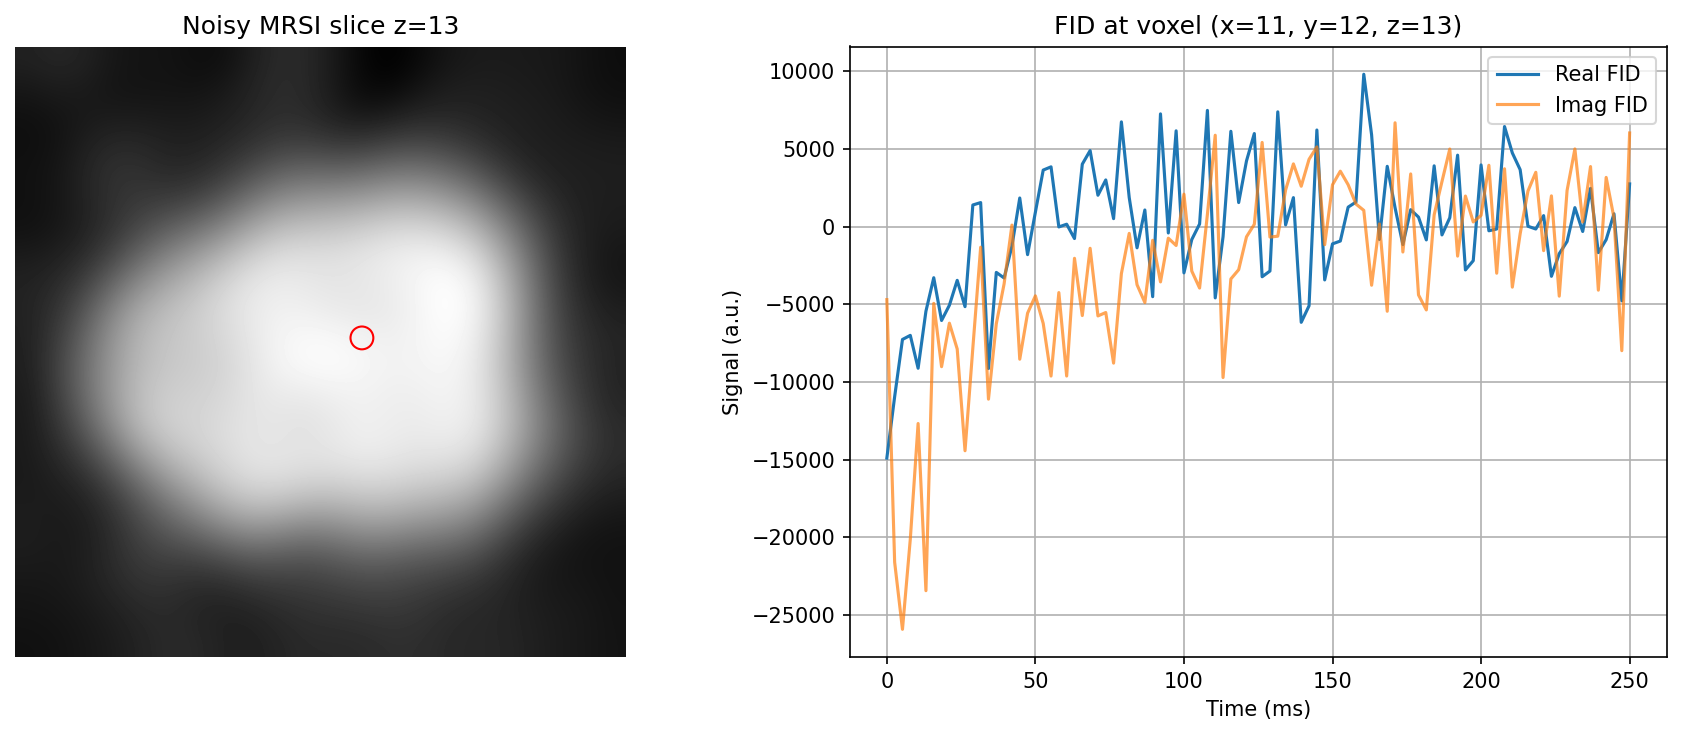

In [ ]:
#Original noisy data FID.
plot_image_with_full_FID(
    vol_noisy, noisy_subj_t,
    x, y, z,
    dt=dt,
    title="Noisy MRSI",
    phase_idx=phase_idx
)

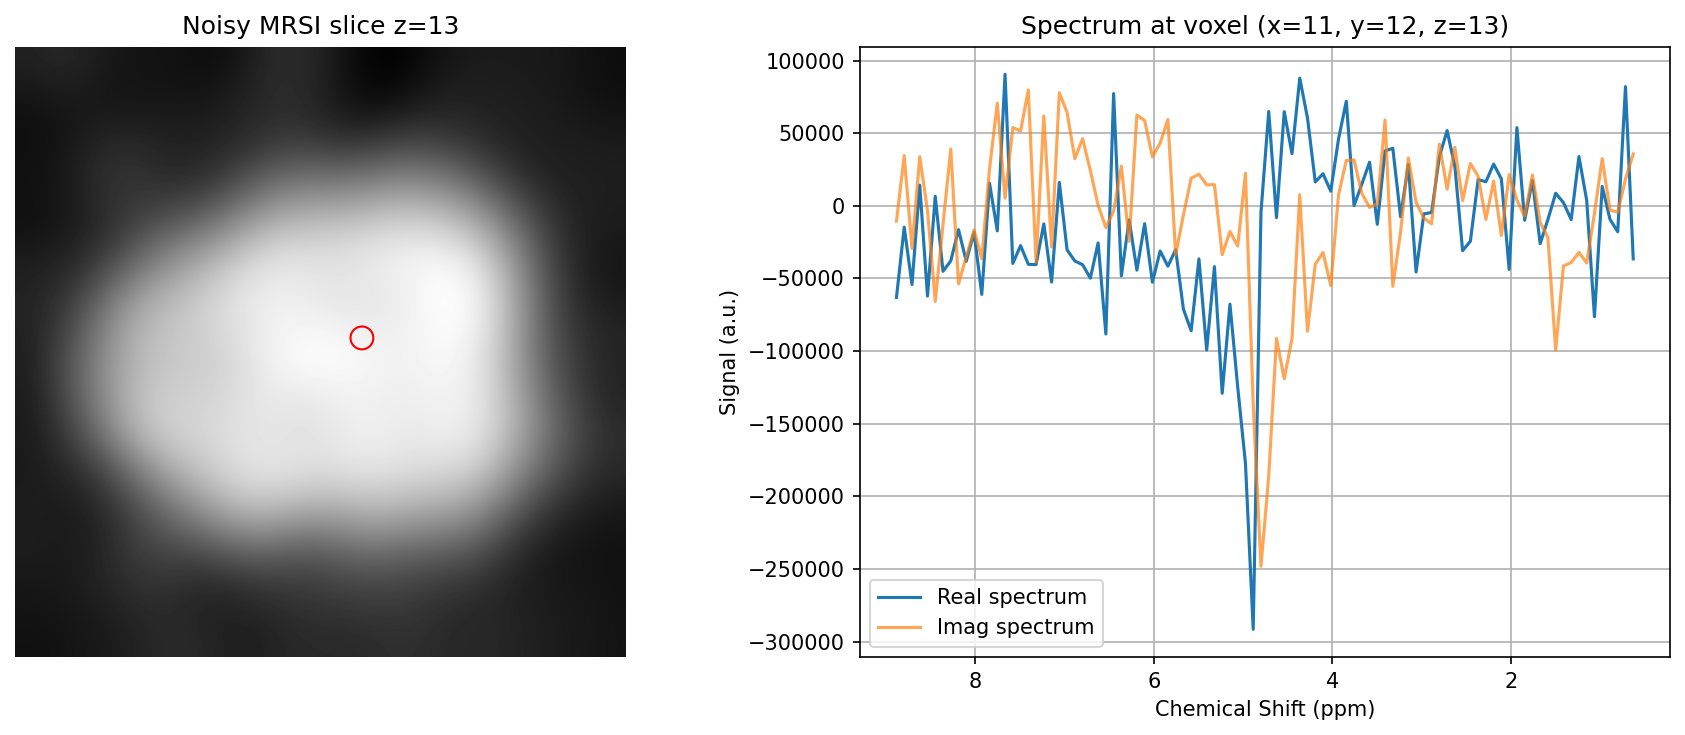

In [ ]:
#Original noisy data ppm
plot_image_with_full_spectrum_ppm(
    vol_noisy, noisy_subj_t,
    x, y, z,
    dt=dt,
    f0=f0,
    center_ppm=center_ppm,
    title="Noisy MRSI",
    phase_idx=phase_idx
)

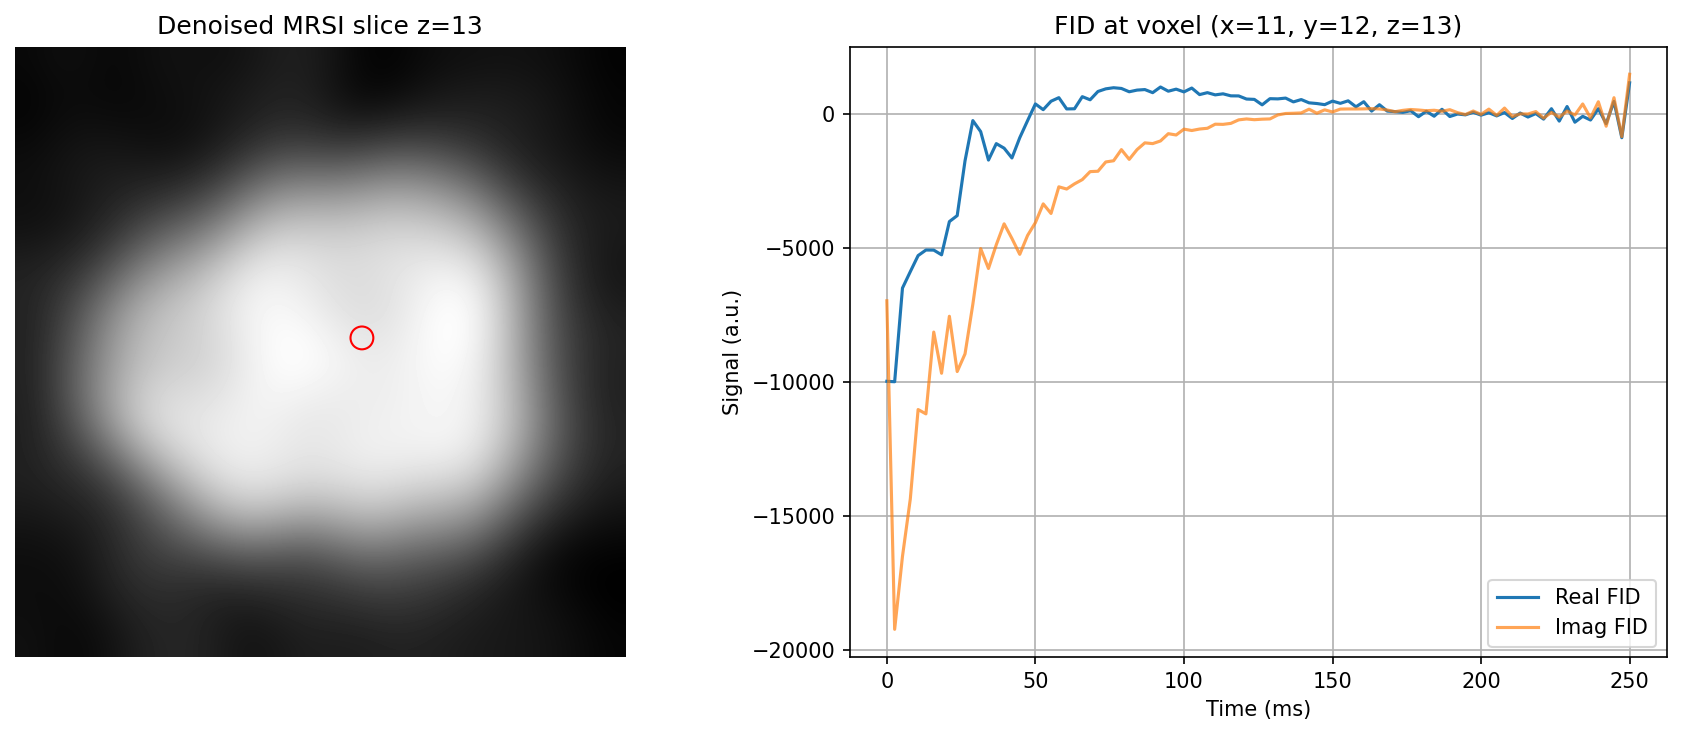

In [ ]:
#denoised data FID.
plot_image_with_full_FID(
    vol_denoised, denoised_subj_t,
    x, y, z,
    dt=dt,
    title="Denoised MRSI",
    phase_idx=phase_idx
)


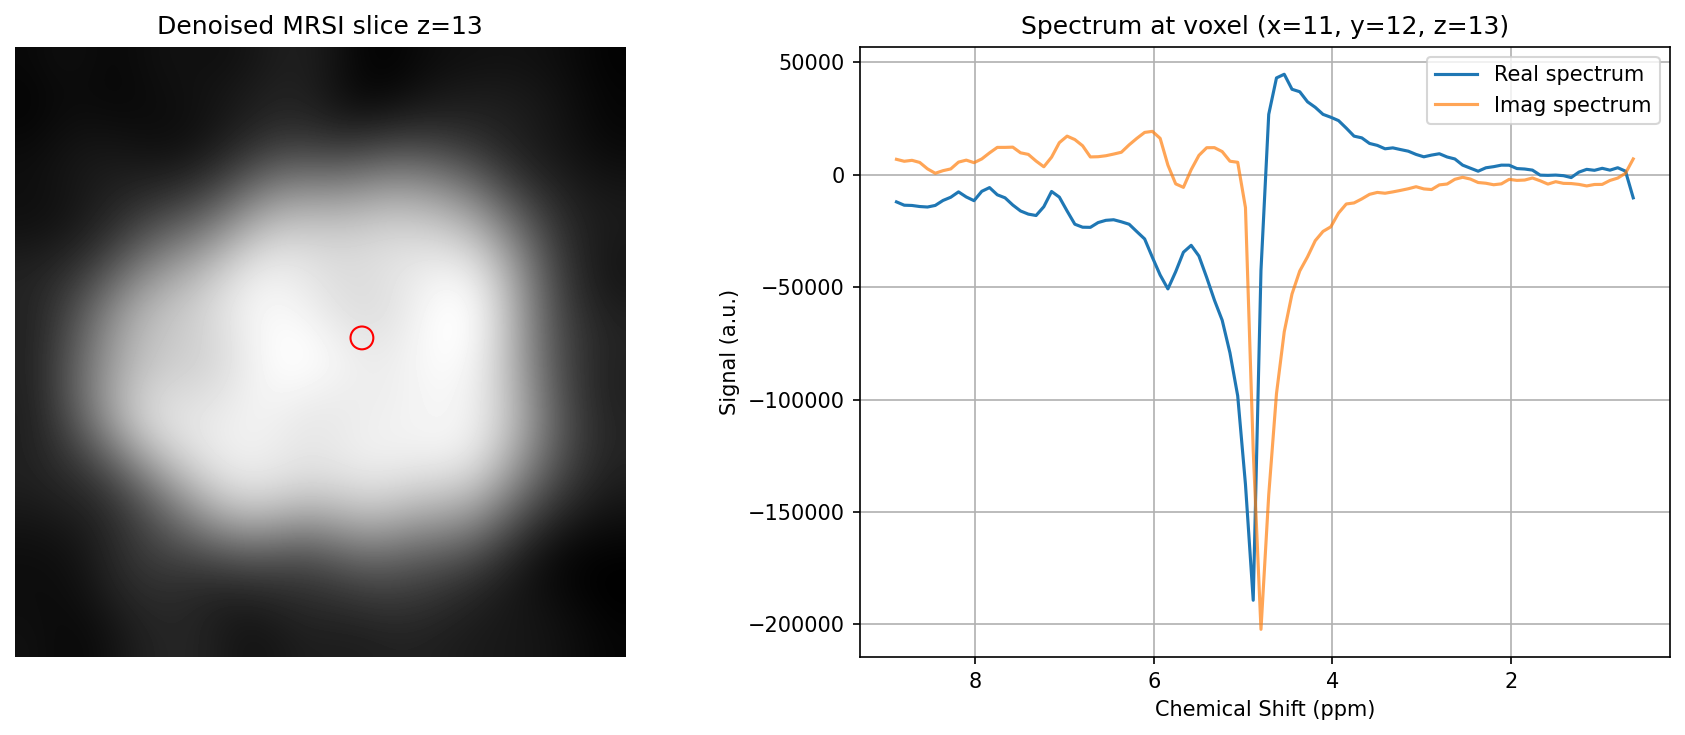

In [ ]:
#denoised data ppm
plot_image_with_full_spectrum_ppm(
    vol_denoised, denoised_subj_t,
    x, y, z,
    dt=dt,
    f0=f0,
    center_ppm=center_ppm,
    title="Denoised MRSI",
    phase_idx=phase_idx
)

In [ ]:
#plot only the magniture
import numpy as np
import matplotlib.pyplot as plt

def plot_FID_mag_side_by_side(noisy_t, denoised_t, x, y, z, dt, phase_idx=0):
    # extract FIDs
    FID_noisy = noisy_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    FID_den   = denoised_t[x, y, z, :, phase_idx].detach().cpu().numpy()

    # magnitude
    mag_noisy = np.abs(FID_noisy)
    mag_den   = np.abs(FID_den)

    # time axis in ms
    t = np.arange(len(FID_noisy)) * dt * 1e3

    plt.figure(figsize=(12,4), dpi=150)

    # noisy
    plt.subplot(1,2,1)
    plt.plot(t, mag_noisy, linewidth=2)
    plt.title("Noisy FID magnitude")
    plt.xlabel("Time (ms)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)

    # denoised
    plt.subplot(1,2,2)
    plt.plot(t, mag_den, color="green", linewidth=2)
    plt.title("Denoised FID magnitude")
    plt.xlabel("Time (ms)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


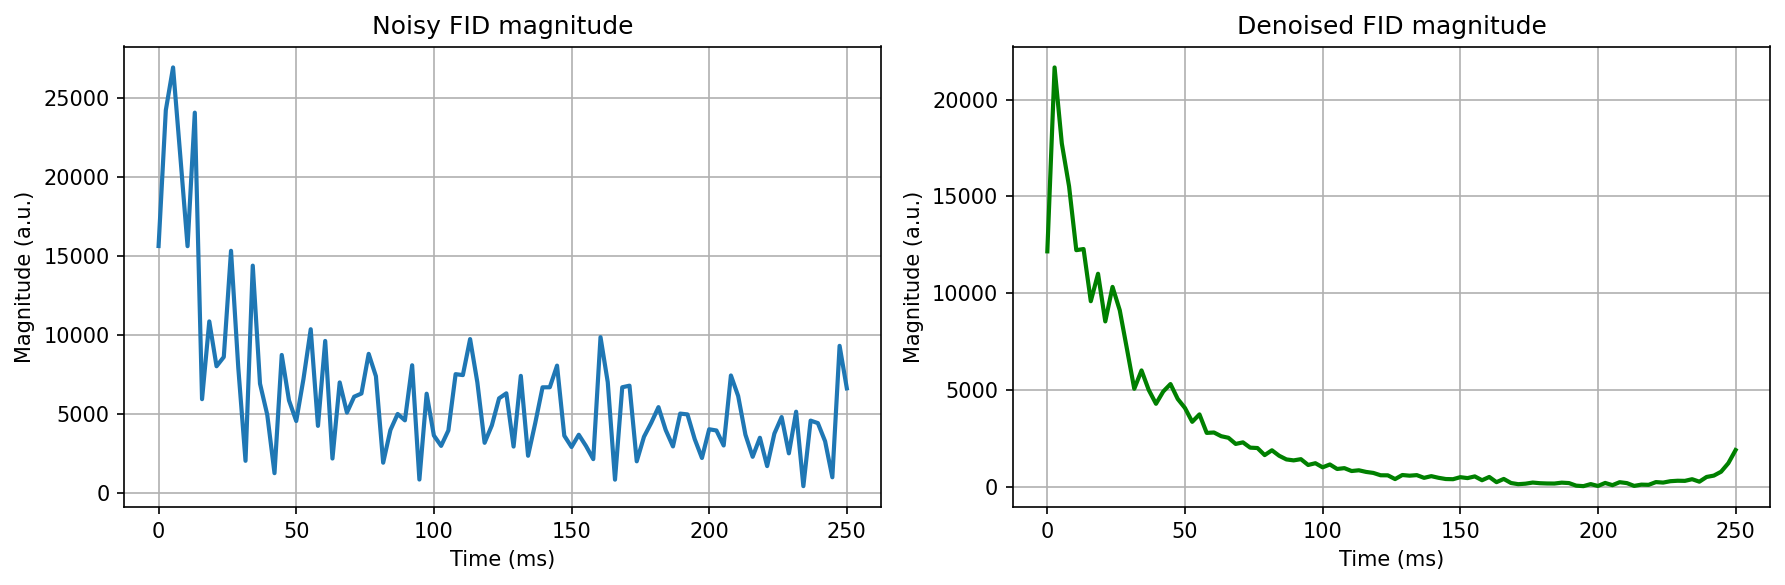

In [ ]:
#plot noisy and denoised fid magnitude side by side
plot_FID_mag_side_by_side(
    noisy_subj_t,
    denoised_subj_t,
    x, y, z,
    dt,
    phase_idx
)

In [ ]:
#plot noisy and denoised spectrum magnitude side by side
def plot_spectrum_mag_side_by_side(noisy_t, denoised_t,
                                   x, y, z, dt, f0, center_ppm=4.8,
                                   phase_idx=0):
    # extract FIDs
    FID_noisy = noisy_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    FID_den   = denoised_t[x, y, z, :, phase_idx].detach().cpu().numpy()

    # FFT → spectra
    Spec_noisy = np.fft.fftshift(np.fft.fft(FID_noisy))
    Spec_den   = np.fft.fftshift(np.fft.fft(FID_den))

    # ppm axis
    n = len(Spec_noisy)
    Fs = 1.0 / dt
    freq_Hz = np.linspace(-Fs/2, Fs/2, n, endpoint=False)
    ppm = center_ppm + freq_Hz * 1e6 / f0

    # magnitude
    mag_noisy = np.abs(Spec_noisy)
    mag_den   = np.abs(Spec_den)

    plt.figure(figsize=(12,4), dpi=150)

    # noisy
    plt.subplot(1,2,1)
    plt.plot(ppm, mag_noisy, linewidth=2)
    plt.gca().invert_xaxis()
    plt.title("Noisy spectrum (magnitude)")
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)

    # denoised
    plt.subplot(1,2,2)
    plt.plot(ppm, mag_den, color="green", linewidth=2)
    plt.gca().invert_xaxis()
    plt.title("Denoised spectrum (magnitude)")
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


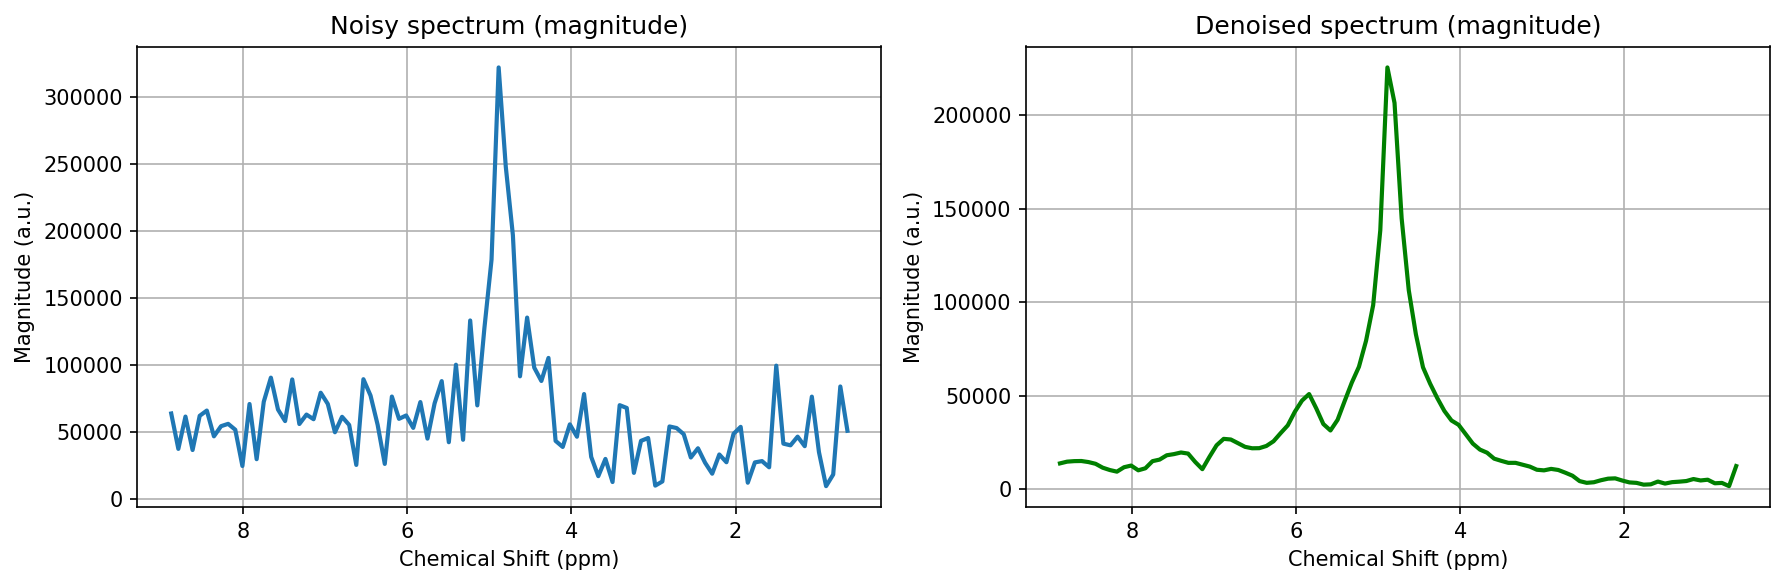

In [ ]:
#plot noisy and denoised fid magnitude side by side
plot_spectrum_mag_side_by_side(
    noisy_subj_t,
    denoised_subj_t,
    x, y, z,
    dt,
    f0,
    center_ppm,
    phase_idx
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_FID_realimag_and_mag_side_by_side(
        noisy_t, denoised_t,
        x, y, z, dt,
        phase_idx=0):

    # Extract FIDs
    FID_noisy = noisy_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    FID_den   = denoised_t[x, y, z, :, phase_idx].detach().cpu().numpy()

    # Components
    real_noisy = np.real(FID_noisy)
    imag_noisy = np.imag(FID_noisy)
    real_den   = np.real(FID_den)
    imag_den   = np.imag(FID_den)

    # Magnitudes
    mag_noisy = np.abs(FID_noisy)
    mag_den   = np.abs(FID_den)

    # Time axis (ms)
    t = np.arange(len(FID_noisy)) * dt * 1e3

    # ---- Plotting ----
    plt.figure(figsize=(14,5), dpi=150)

    # Left: real + imag
    plt.subplot(1,2,1)
    plt.plot(t, real_noisy, label="Noisy real")
    plt.plot(t, imag_noisy, label="Noisy imag")
    plt.plot(t, real_den, "--", label="Denoised real", color="green")
    plt.plot(t, imag_den, "--", label="Denoised imag", color="red")
    plt.title(f"FID real + imag at (x={x}, y={y}, z={z})")
    plt.xlabel("Time (ms)")
    plt.ylabel("Signal (a.u.)")
    plt.grid(True)
    plt.legend()

    # Right: magnitude
    plt.subplot(1,2,2)
    plt.plot(t, mag_noisy, label="Noisy magnitude")
    plt.plot(t, mag_den, label="Denoised magnitude", color="orange")
    plt.title(f"FID magnitude at (x={x}, y={y}, z={z})")
    plt.xlabel("Time (ms)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


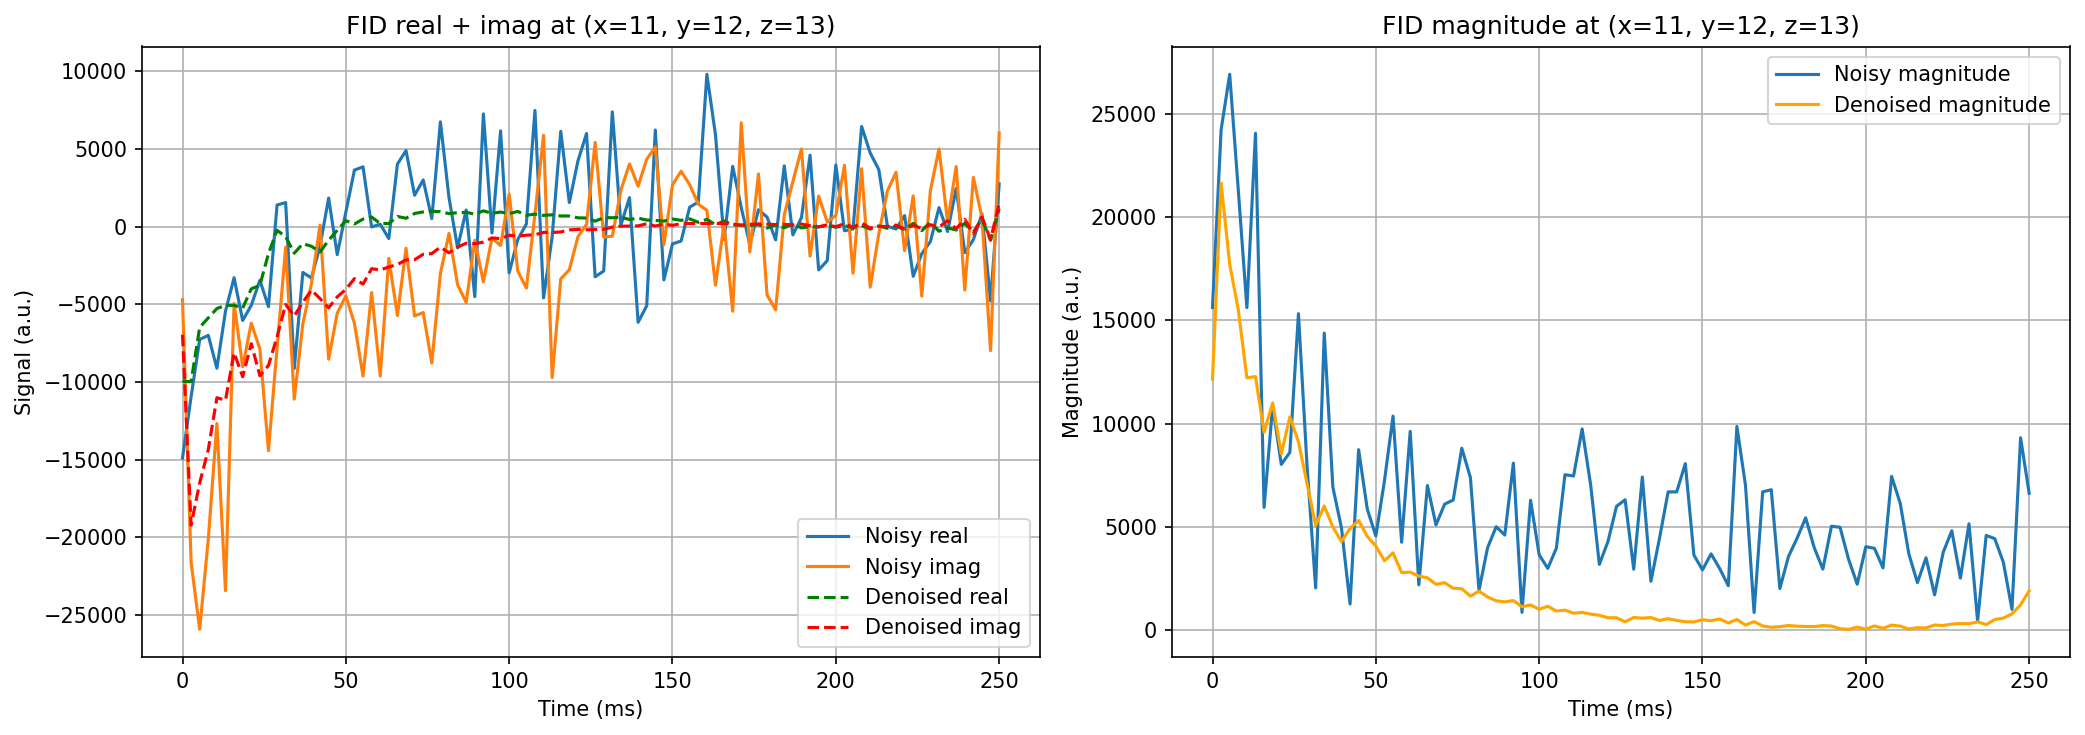

In [ ]:
plot_FID_realimag_and_mag_side_by_side(
    noisy_subj_t,
    denoised_subj_t,
    x, y, z,
    dt,
    phase_idx
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spectrum_realimag_and_mag_side_by_side(
        noisy_t, denoised_t,
        x, y, z,
        dt, f0, center_ppm=4.8,
        phase_idx=0):

    # Extract FIDs
    FID_noisy = noisy_t[x, y, z, :, phase_idx].detach().cpu().numpy()
    FID_den   = denoised_t[x, y, z, :, phase_idx].detach().cpu().numpy()

    # FFT → spectra
    Spec_noisy = np.fft.fftshift(np.fft.fft(FID_noisy))
    Spec_den   = np.fft.fftshift(np.fft.fft(FID_den))

    # ppm axis
    n = len(Spec_noisy)
    Fs = 1.0 / dt
    freq_Hz = np.linspace(-Fs/2, Fs/2, n, endpoint=False)
    ppm = center_ppm + (freq_Hz * 1e6 / f0)

    # components
    real_noisy = np.real(Spec_noisy)
    imag_noisy = np.imag(Spec_noisy)
    real_den   = np.real(Spec_den)
    imag_den   = np.imag(Spec_den)

    # magnitude
    mag_noisy = np.abs(Spec_noisy)
    mag_den   = np.abs(Spec_den)

    # ---- Plotting ----
    plt.figure(figsize=(14,5), dpi=150)

    # left: real + imag
    plt.subplot(1,2,1)
    plt.plot(ppm, real_noisy, label="Noisy real")
    plt.plot(ppm, imag_noisy, label="Noisy imag")
    plt.plot(ppm, real_den, "--", label="Denoised real", color="green")
    plt.plot(ppm, imag_den, "--", label="Denoised imag", color="red")
    plt.gca().invert_xaxis()
    plt.title(f"Spectrum real + imag at (x={x}, y={y}, z={z})")
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Signal (a.u.)")
    plt.grid(True)
    plt.legend()

    # right: magnitude
    plt.subplot(1,2,2)
    plt.plot(ppm, mag_noisy, label="Noisy magnitude")
    plt.plot(ppm, mag_den, label="Denoised magnitude", color="orange")
    plt.gca().invert_xaxis()
    plt.title(f"Spectrum magnitude at (x={x}, y={y}, z={z})")
    plt.xlabel("Chemical Shift (ppm)")
    plt.ylabel("Magnitude (a.u.)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


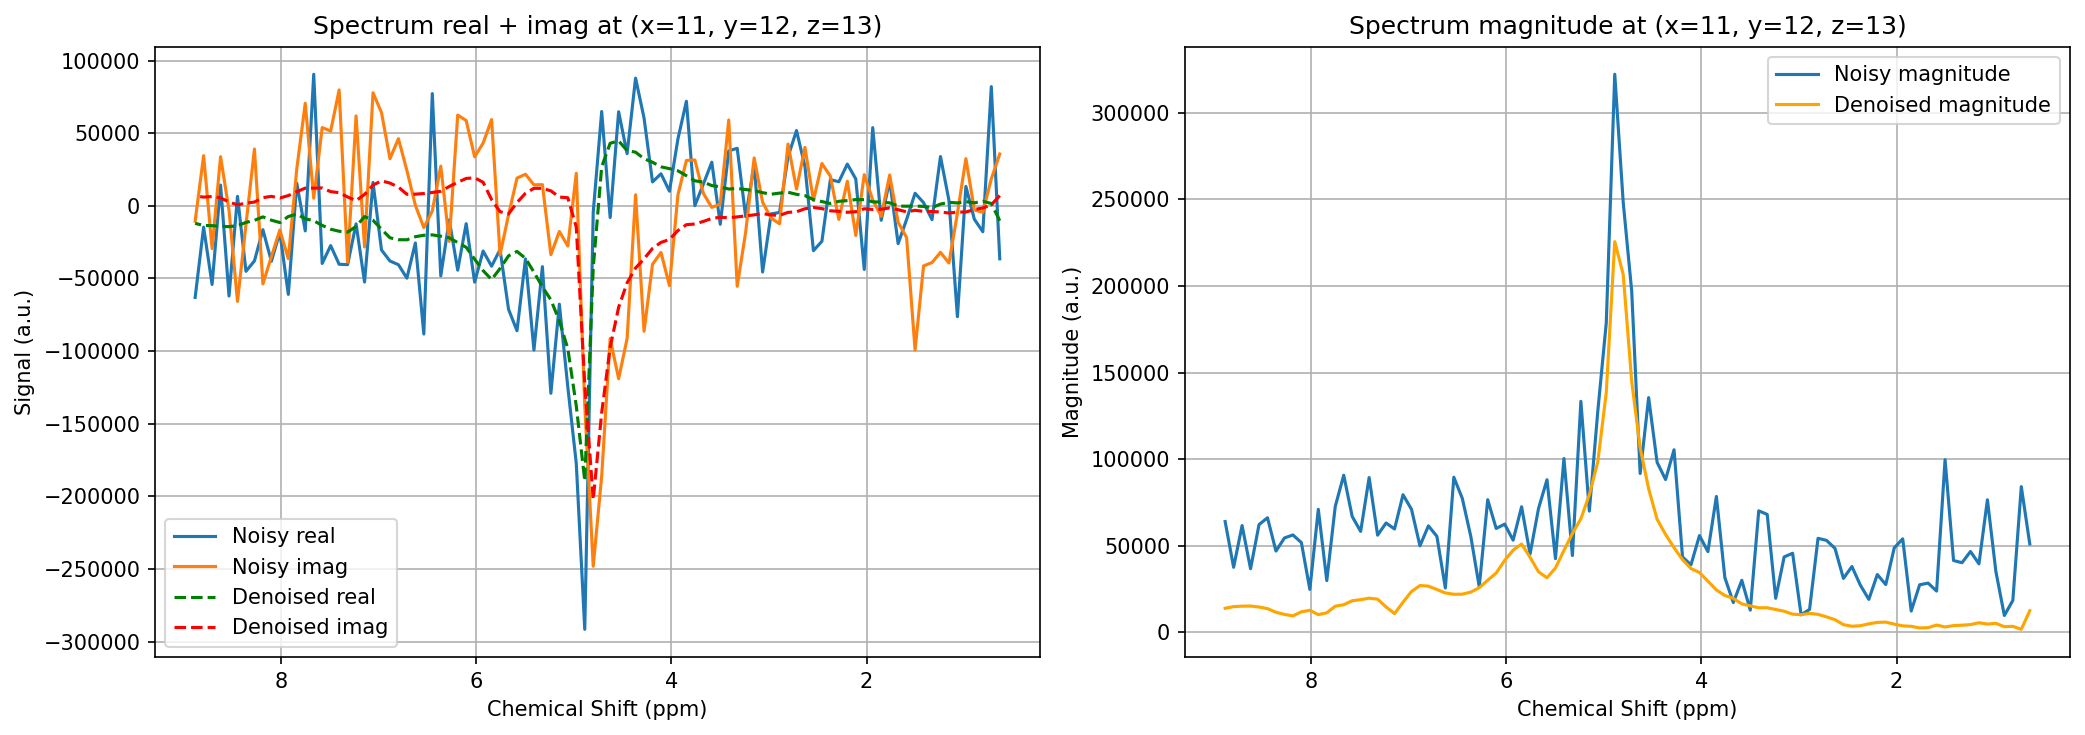

In [ ]:
plot_spectrum_realimag_and_mag_side_by_side(
    noisy_subj_t,
    denoised_subj_t,
    x, y, z,
    dt,
    f0,
    center_ppm,
    phase_idx
)
